# Production notebook building masking like an agent would do it

The goal of this notebook is to go through what an agent should do when producing a mask for a given run, and use this exploration to identify simplifications and clarifications necessary in the codebase.

**Plan** (input = RUN):
1. Explore content of the run + associated calibration data 
```python
list_contents(RUN)
# Should list number of shots, different properties, number of shots available per property, calibration data available
# Geometry of the detector etc ...
```
2. Shot selection : based on content, decide on several shot selections and run them
```python
select_shots(...) # Selection 1
select_shots(...) # Selection 2
select_shots(...) # Selection 3
display_shots() # Displays shots together for visual analysis and refine/discard some if necessary
```
3. Masking : based on observed shots, decide what masking tools to use and apply them (always apply geometry + calib first)
```python
detector(...) # Masking : includes stats, regularization etc ...
display_masks() # Display each mask obtained and refine parameters or tools if necessary
```
4. Validation : based on obtained masks, apply validation methods to refine previous behavior if necessary
```python
raise(NotImplemented)
```

In [1]:
from automask.utils import configure_psana_environment

PSANA_ENVIRONMENT = configure_psana_environment()

## 0. Experiment content

This first stage only identifies the experiment and resolves the files relevant to the requested run and detector. It does not open or analyze any data. In practice, the agent should recover this context; it is explicit here so the notebook remains reproducible.

Inputs to clarify before starting:
1. Experiment name
2. Run number
3. Detector alias, psana source, and calibration type
4. Data paths: find the run's `.xtc` streams and the detector calibration files applicable to that run.

Expected output:
```markdown
Experiment: ""
Run: ""
Detector: ""
Relevant files:
- XTC files (Markdown table)
- Applicable detector calibration files (Markdown table)
```

In [2]:
# Hardcoded information for this run

from automask.io.read_xtc import JUNGFRAU_NAME

EXPERIMENT_NAME = 'xppl1016922'
RUN = 475
DETECTOR_NAME = JUNGFRAU_NAME
DETECTOR_SOURCE = 'XppEndstation.0:Jungfrau.0'
DETECTOR_CALIB_TYPE = 'Jungfrau::CalibV1'

In [3]:
from automask.utils import (
    list_experiment_content,
    profile_run_values,
    print_detector_geometry,
    print_small_data_inventory,
)

In [4]:
experiment_content = list_experiment_content(
    EXPERIMENT_NAME, RUN, DETECTOR_NAME, DETECTOR_SOURCE, DETECTOR_CALIB_TYPE
)
xtc = experiment_content['xtc']

**Experiment:** `xppl1016922`  
**Run:** `0475`  
**Detector:** `jungfrau1M_alcove` (`XppEndstation.0:Jungfrau.0`)

### Relevant XTC files

| file | stream | chunk | size | path |
| --- | --- | --- | --- | --- |
| xppl1016922-r0475-s00-c00.xtc | s00 | c00 | 1.27 GiB | /Data/hippolyte.wallaert/LCLS/xtc/xppl1016922-r0475-s00-c00.xtc |
| xppl1016922-r0475-s01-c00.xtc | s01 | c00 | 1.27 GiB | /Data/hippolyte.wallaert/LCLS/xtc/xppl1016922-r0475-s01-c00.xtc |

### Applicable detector calibration files

| constant | run range | size | path |
| --- | --- | --- | --- |
| dark_max | 362–end | 21.00 MiB | /users/eleves-a/2022/hippolyte.wallaert/LCLS/calib/JungfrauCalibV1/XppEndstation.0Jungfrau.0/dark_max/362-end.data |
| dark_min | 362–end | 21.00 MiB | /users/eleves-a/2022/hippolyte.wallaert/LCLS/calib/JungfrauCalibV1/XppEndstation.0Jungfrau.0/dark_min/362-end.data |
| geometry | 0–end | 1.71 KiB | /users/eleves-a/2022/hippolyte.wallaert/LCLS/calib/JungfrauCalibV1/XppEndstation.0Jungfrau.0/geometry/0-end.data |
| pedestals | 362–end | 28.99 MiB | /users/eleves-a/2022/hippolyte.wallaert/LCLS/calib/JungfrauCalibV1/XppEndstation.0Jungfrau.0/pedestals/362-end.data |
| pixel_gain | 110–end | 24.00 MiB | /users/eleves-a/2022/hippolyte.wallaert/LCLS/calib/JungfrauCalibV1/XppEndstation.0Jungfrau.0/pixel_gain/110-end.data |
| pixel_offset | 110–end | 14.98 MiB | /users/eleves-a/2022/hippolyte.wallaert/LCLS/calib/JungfrauCalibV1/XppEndstation.0Jungfrau.0/pixel_offset/110-end.data |
| pixel_rms | 362–end | 18.32 MiB | /users/eleves-a/2022/hippolyte.wallaert/LCLS/calib/JungfrauCalibV1/XppEndstation.0Jungfrau.0/pixel_rms/362-end.data |
| pixel_status | 362–end | 15.00 MiB | /users/eleves-a/2022/hippolyte.wallaert/LCLS/calib/JungfrauCalibV1/XppEndstation.0Jungfrau.0/pixel_status/362-end.data |

## 1. Analysis of the listed files

This stage is reached once the available files and XTC keys have been listed and the useful values selected. It retrieves those values, reads the detector geometry and small-data content, and analyzes the relevant calibration constants. 

At this stage, available and confirmed information should be:
1. RUN
2. Experiment name
3. Detector alias 
4. XTC and calibration files

### Profile XTC and EPICS values, geometry, and small-data content

The run profiler discovers payloads directly from `event.keys()` and extracts the known numeric fields from every decoded event. After each event it also records the current value of every process variable in `data_source.env().epicsStore()`, including both its alias and underlying PV name. It does not require experiment-specific payload or value definitions.

```python
run_profile = profile_run_values(RUN)
print_detector_geometry(RUN)
print_small_data_inventory(RUN)
```

In [5]:
run_profile = profile_run_values(RUN)
print_detector_geometry(RUN)
print_small_data_inventory(RUN)

could not find EPICS PV lxt_ttc in data
could not find EPICS PV las_opa_wp in data
Timetool detector not found in data.


### Raw XTC payloads (1,280 decoded events)

| source | alias | type | key | coverage | read errors |
| --- | --- | --- | --- | --- | --- |
| BldInfo(EBeam) | — | Bld.BldDataEBeamV7 | — | 100.0% | 0 |
| BldInfo(FEE-SPEC0) | — | Bld.BldDataSpectrometerV1 | — | 77.7% | 0 |
| BldInfo(FEEGasDetEnergy) | — | Bld.BldDataFEEGasDetEnergyV1 | — | 99.9% | 0 |
| BldInfo(HX2-SB1-BMMON) | — | Bld.BldDataBeamMonitorV1 | — | 100.0% | 0 |
| BldInfo(PhaseCavity) | — | Bld.BldDataPhaseCavityV1 | — | 99.1% | 0 |
| BldInfo(XPP-AIN-01) | — | Bld.BldDataAnalogInputV1 | — | 100.0% | 0 |
| BldInfo(XPP-SB2-BMMON) | — | Bld.BldDataBeamMonitorV1 | — | 100.0% | 0 |
| BldInfo(XPP-SB3-BMMON) | — | Bld.BldDataBeamMonitorV1 | — | 100.0% | 0 |
| BldInfo(XppEnds_Ipm0) | — | Ipimb.DataV2 | — | 100.0% | 0 |
| BldInfo(XppEnds_Ipm0) | — | Lusi.IpmFexV1 | — | 100.0% | 0 |
| BldInfo(XppMon_Pim0) | — | Ipimb.DataV2 | — | 100.0% | 0 |
| BldInfo(XppMon_Pim0) | — | Lusi.IpmFexV1 | — | 100.0% | 0 |
| BldInfo(XppMon_Pim1) | — | Ipimb.DataV2 | — | 100.0% | 0 |
| BldInfo(XppMon_Pim1) | — | Lusi.IpmFexV1 | — | 100.0% | 0 |
| BldInfo(XppSb3_Pim) | — | Ipimb.DataV2 | — | 100.0% | 0 |
| BldInfo(XppSb3_Pim) | — | Lusi.IpmFexV1 | — | 100.0% | 0 |
| DetInfo(NoDetector.0:Evr.0) | evr0 | EvrData.DataV4 | — | 100.0% | 0 |
| DetInfo(XppEndstation.0:Jungfrau.0) | jungfrau1M_alcove | Jungfrau.ElementV2 | — | 100.0% | 1280 |
| ProcInfo(255.255.255.255, pid=16777215) | — | psana.DgramList | — | 100.0% | 0 |
| ProcInfo(255.255.255.255, pid=16777215) | — | psana.EventId | — | 100.0% | 0 |
| ProcInfo(255.255.255.255, pid=16777215) | — | psana.EventOffset | — | 100.0% | 0 |
| ProcInfo(255.255.255.255, pid=16777215) | — | — | — | 100.0% | 0 |

### Profiled per-shot values

| source | field | type | origin | coverage | variation | observed |
| --- | --- | --- | --- | --- | --- | --- |
| BldInfo(PhaseCavity)/Bld.BldDataPhaseCavityV1 | charge1 | Bld.BldDataPhaseCavityV1 | psana payload | 99.1% | continuous; 1239 values | p05=7.333e+04, median=7.509e+04, p95=7.7e+04 |
| BldInfo(PhaseCavity)/Bld.BldDataPhaseCavityV1 | charge2 | Bld.BldDataPhaseCavityV1 | psana payload | 99.1% | continuous; 784 values | p05=37.2, median=96.6, p95=191.3 |
| BldInfo(PhaseCavity)/Bld.BldDataPhaseCavityV1 | fitTime1 | Bld.BldDataPhaseCavityV1 | psana payload | 99.1% | continuous; 720 values | p05=-0.8869, median=-0.6773, p95=-0.4483 |
| BldInfo(PhaseCavity)/Bld.BldDataPhaseCavityV1 | fitTime2 | Bld.BldDataPhaseCavityV1 | psana payload | 99.1% | continuous; 1267 values | p05=-111.1, median=7.049, p95=131.1 |
| DetInfo(NoDetector.0:Evr.0) | eventCode[119] | EvrData.DataV4 | psana EVR | 100.0% | constant | 1 |
| DetInfo(NoDetector.0:Evr.0) | eventCode[137] | EvrData.DataV4 | psana EVR | 100.0% | 2 values; 22 changes | 0: 11, 1: 1269 |
| DetInfo(NoDetector.0:Evr.0) | eventCode[140] | EvrData.DataV4 | psana EVR | 100.0% | constant | 1 |
| DetInfo(NoDetector.0:Evr.0) | eventCode[141] | EvrData.DataV4 | psana EVR | 100.0% | 2 values; 729 changes | 0: 626, 1: 654 |
| DetInfo(NoDetector.0:Evr.0) | eventCode[142] | EvrData.DataV4 | psana EVR | 100.0% | 2 values; 551 changes | 0: 967, 1: 313 |
| DetInfo(NoDetector.0:Evr.0) | eventCode[143] | EvrData.DataV4 | psana EVR | 100.0% | 2 values; 208 changes | 0: 1176, 1: 104 |
| DetInfo(NoDetector.0:Evr.0) | eventCode[144] | EvrData.DataV4 | psana EVR | 100.0% | 2 values; 112 changes | 0: 1224, 1: 56 |
| DetInfo(NoDetector.0:Evr.0) | eventCode[145] | EvrData.DataV4 | psana EVR | 100.0% | 2 values; 26 changes | 0: 1267, 1: 13 |
| DetInfo(NoDetector.0:Evr.0) | eventCode[146] | EvrData.DataV4 | psana EVR | 100.0% | 2 values; 14 changes | 0: 1273, 1: 7 |
| DetInfo(NoDetector.0:Evr.0) | eventCode[162] | EvrData.DataV4 | psana EVR | 100.0% | 2 values; 22 changes | 0: 1269, 1: 11 |
| DetInfo(NoDetector.0:Evr.0) | eventCode[30] | EvrData.DataV4 | psana EVR | 100.0% | constant | 1 |
| DetInfo(NoDetector.0:Evr.0) | eventCode[31] | EvrData.DataV4 | psana EVR | 100.0% | 2 values; 729 changes | 0: 626, 1: 654 |
| DetInfo(NoDetector.0:Evr.0) | eventCode[32] | EvrData.DataV4 | psana EVR | 100.0% | 2 values; 551 changes | 0: 967, 1: 313 |
| DetInfo(NoDetector.0:Evr.0) | eventCode[33] | EvrData.DataV4 | psana EVR | 100.0% | 2 values; 208 changes | 0: 1176, 1: 104 |
| DetInfo(NoDetector.0:Evr.0) | eventCode[34] | EvrData.DataV4 | psana EVR | 100.0% | 2 values; 112 changes | 0: 1224, 1: 56 |
| DetInfo(NoDetector.0:Evr.0) | eventCode[35] | EvrData.DataV4 | psana EVR | 100.0% | 2 values; 26 changes | 0: 1267, 1: 13 |
| DetInfo(NoDetector.0:Evr.0) | eventCode[36] | EvrData.DataV4 | psana EVR | 100.0% | 2 values; 14 changes | 0: 1273, 1: 7 |
| DetInfo(NoDetector.0:Evr.0) | eventCode[40] | EvrData.DataV4 | psana EVR | 100.0% | constant | 1 |
| DetInfo(NoDetector.0:Evr.0) | eventCode[41] | EvrData.DataV4 | psana EVR | 100.0% | 2 values; 729 changes | 0: 626, 1: 654 |
| DetInfo(NoDetector.0:Evr.0) | eventCode[42] | EvrData.DataV4 | psana EVR | 100.0% | 2 values; 551 changes | 0: 967, 1: 313 |
| DetInfo(NoDetector.0:Evr.0) | eventCode[43] | EvrData.DataV4 | psana EVR | 100.0% | 2 values; 208 changes | 0: 1176, 1: 104 |
| DetInfo(NoDetector.0:Evr.0) | eventCode[44] | EvrData.DataV4 | psana EVR | 100.0% | 2 values; 112 changes | 0: 1224, 1: 56 |
| DetInfo(NoDetector.0:Evr.0) | eventCode[45] | EvrData.DataV4 | psana EVR | 100.0% | 2 values; 26 changes | 0: 1267, 1: 13 |
| DetInfo(NoDetector.0:Evr.0) | eventCode[46] | EvrData.DataV4 | psana EVR | 100.0% | 2 values; 14 changes | 0: 1273, 1: 7 |
| DetInfo(NoDetector.0:Evr.0) | eventCode[90] | EvrData.DataV4 | psana EVR | 100.0% | 2 values; 639 changes | 0: 415, 1: 865 |
| DetInfo(NoDetector.0:Evr.0) | eventCode[91] | EvrData.DataV4 | psana EVR | 100.0% | 2 values; 639 changes | 0: 865, 1: 415 |
| DetInfo(XppEndstation.0:Jungfrau.0)/Jungfrau.ElementV2 | fiducials | Jungfrau.ElementV2 | psana payload | 100.0% | continuous; 1280 values | p05=4.552e+04, median=4.984e+04, p95=5.415e+04 |
| DetInfo(XppEndstation.0:Jungfrau.0)/Jungfrau.ElementV2 | frameNumber | Jungfrau.ElementV2 | psana payload | 100.0% | continuous; 1280 values | p05=3.975e+05, median=3.99e+05, p95=4.004e+05 |
| DetInfo(XppEndstation.0:Jungfrau.0)/Jungfrau.ElementV2 | moduleInfo_shape[0] | Jungfrau.ElementV2 | psana payload | 100.0% | constant | 2 |
| DetInfo(XppEndstation.0:Jungfrau.0)/Jungfrau.ElementV2 | ticks | Jungfrau.ElementV2 | psana payload | 100.0% | 3 values; 735 changes | 328166: 35, 329832: 614, 331498: 631 |
| ProcInfo(255.255.255.255, pid=16777215)/psana.DgramList | getFileNames[0] | psana.DgramList | psana payload | 100.0% | 2 values; 990 changes | /Data/hippolyte.wallaert/LCLS/xtc/xppl1016922-r0475-s00-c00.xtc: 640, /Data/hippolyte.wallaert/LCLS/xtc/xppl1016922-r0475-s01-c00.xtc: 640 |
| ProcInfo(255.255.255.255, pid=16777215)/psana.DgramList | getOffsets[0] | psana.DgramList | psana payload | 100.0% | continuous; 1278 values | p05=6.782e+07, median=6.785e+08, p95=1.29e+09 |
| ProcInfo(255.255.255.255, pid=16777215)/psana.EventId | fiducials | psana.EventId | psana payload | 100.0% | continuous; 1280 values | p05=4.552e+04, median=4.984e+04, p95=5.415e+04 |
| ProcInfo(255.255.255.255, pid=16777215)/psana.EventId | idxtime | psana.EventId | psana payload | 100.0% | 1280 values; 1279 changes | <psana.EventTime(@0x7f1bcfd01110)>: 1, <psana.EventTime(@0x7f1bcfd431d0)>: 1, <psana.EventTime(@0x7f1bcfd46f90)>: 1, <psana.EventTime(@0x7f1bcfd46fb0)>: 1, <psana.EventTime(@0x7f1bcfd4ad50)>: 1, <psana.EventTime(@0x7f1bcfd4eb50)>: 1, <psana.EventTime(@0x7f1bcfd52950)>: 1, <psana.EventTime(@0x7f1bcfd57650)>: 1, <psana.EventTime(@0x7f1bcfd5c470)>: 1, <psana.EventTime(@0x7f1bcfd5c510)>: 1, <psana.EventTime(@0x7f1bcfd602f0)>: 1, <psana.EventTime(@0x7f1bcfd6cbb0)>: 1, <psana.EventTime(@0x7f1bcfd85230)>: 1, <psana.EventTime(@0x7f1bcfd852d0)>: 1, <psana.EventTime(@0x7f1bcfd89090)>: 1, <psana.EventTime(@0x7f1bcfd8ddb0)>: 1, <psana.EventTime(@0x7f1bcfd95990)>: 1, <psana.EventTime(@0x7f1bcfd959b0)>: 1, <psana.EventTime(@0x7f1bcfda3350)>: 1, <psana.EventTime(@0x7f1bcfda7090)>: 1, <psana.EventTime(@0x7f1bcfda70f0)>: 1, <psana.EventTime(@0x7f1bcfdaec50)>: 1, <psana.EventTime(@0x7f1bcfdb2a30)>: 1, <psana.EventTime(@0x7f1bcfdb6870)>: 1, <psana.EventTime(@0x7f1bcfdc3450)>: 1, <psana.EventTime(@0x7f1bcfdc8270)>: 1, <psana.EventTime(@0x7f1bcfdd0e10)>: 1, <psana.EventTime(@0x7f1bcfdd4b90)>: 1, <psana.EventTime(@0x7f1bcfdd4c30)>: 1, <psana.EventTime(@0x7f1bcfdd89b0)>: 1, <psana.EventTime(@0x7f1bcfddc7d0)>: 1, <psana.EventTime(@0x7f1bcfde0570)>: 1, <psana.EventTime(@0x7f1bcfde90f0)>: 1, <psana.EventTime(@0x7f1bcfdecf30)>: 1, <psana.EventTime(@0x7f1bcfdf0c90)>: 1, <psana.EventTime(@0x7f1bcfdf4ad0)>: 1, <psana.EventTime(@0x7f1bcfdf88b0)>: 1, <psana.EventTime(@0x7f1bcfe06590)>: 1, <psana.EventTime(@0x7f1bcfe0a2f0)>: 1, <psana.EventTime(@0x7f1bcfe0a390)>: 1, <psana.EventTime(@0x7f1bcfe0f090)>: 1, <psana.EventTime(@0x7f1bcfe0f0f0)>: 1, <psana.EventTime(@0x7f1bcfe16cb0)>: 1, <psana.EventTime(@0x7f1bcfe1aa50)>: 1, <psana.EventTime(@0x7f1bcfe1e7b0)>: 1, <psana.EventTime(@0x7f1bcfe1e830)>: 1, <psana.EventTime(@0x7f1bcfe22690)>: 1, <psana.EventTime(@0x7f1bcfe263d0)>: 1, <psana.EventTime(@0x7f1bcfe26450)>: 1, <psana.EventTime(@0x7f1bcfe2b1d0)>: 1, <psana.EventTime(@0x7f1bcfe2b1f0)>: 1, <psana.EventTime(@0x7f1bcfe2ef10)>: 1, <psana.EventTime(@0x7f1bcfe2ef90)>: 1, <psana.EventTime(@0x7f1bcfe32cf0)>: 1, <psana.EventTime(@0x7f1bcfe32db0)>: 1, <psana.EventTime(@0x7f1bcfe36b10)>: 1, <psana.EventTime(@0x7f1bcfe36b30)>: 1, <psana.EventTime(@0x7f1bcfe36b70)>: 1, <psana.EventTime(@0x7f1bcfe3e630)>: 1, <psana.EventTime(@0x7f1bcfe409d0)>: 1, <psana.EventTime(@0x7f1bcfe409f0)>: 1, <psana.EventTime(@0x7f1bcfe44750)>: 1, <psana.EventTime(@0x7f1bcfe447d0)>: 1, <psana.EventTime(@0x7f1bcfe4c3b0)>: 1, <psana.EventTime(@0x7f1bcfe50110)>: 1, <psana.EventTime(@0x7f1bcfe54e90)>: 1, <psana.EventTime(@0x7f1bcfe58c70)>: 1, <psana.EventTime(@0x7f1bcfe5ca90)>: 1, <psana.EventTime(@0x7f1bcfe5cab0)>: 1, <psana.EventTime(@0x7f1bcfe5caf0)>: 1, <psana.EventTime(@0x7f1bcfe6c1f0)>: 1, <psana.EventTime(@0x7f1bcfe71050)>: 1, <psana.EventTime(@0x7f1bcfe79bf0)>: 1, <psana.EventTime(@0x7f1bcfe7d990)>: 1, <psana.EventTime(@0x7f1bcfe7d9b0)>: 1, <psana.EventTime(@0x7f1bcfe829b0)>: 1, <psana.EventTime(@0x7f1bcfe82a50)>: 1, <psana.EventTime(@0x7f1bcfe867b0)>: 1, <psana.EventTime(@0x7f1bcfe8a630)>: 1, <psana.EventTime(@0x7f1bcfe8e3d0)>: 1, <psana.EventTime(@0x7f1bcfe921d0)>: 1, <psana.EventTime(@0x7f1bcfea2870)>: 1, <psana.EventTime(@0x7f1bcfea2930)>: 1, <psana.EventTime(@0x7f1bcfeaf290)>: 1, <psana.EventTime(@0x7f1bcfeb7e30)>: 1, <psana.EventTime(@0x7f1bcfebcc30)>: 1, <psana.EventTime(@0x7f1bcfebcc50)>: 1, <psana.EventTime(@0x7f1bcfec8850)>: 1, <psana.EventTime(@0x7f1bcfecc650)>: 1, <psana.EventTime(@0x7f1bcfecc670)>: 1, <psana.EventTime(@0x7f1bcfed0410)>: 1, <psana.EventTime(@0x7f1bcfedbdf0)>: 1, <psana.EventTime(@0x7f1bcfee0b30)>: 1, <psana.EventTime(@0x7f1bcfee0bd0)>: 1, <psana.EventTime(@0x7f1bcfee5910)>: 1, <psana.EventTime(@0x7f1bcfeed510)>: 1, <psana.EventTime(@0x7f1bcfef2270)>: 1, <psana.EventTime(@0x7f1bcfef2310)>: 1, <psana.EventTime(@0x7f1bcfef6090)>: 1, <psana.EventTime(@0x7f1bcfef9e10)>: 1, <psana.EventTime(@0x7f1bcfef9eb0)>: 1, <psana.EventTime(@0x7f1bcfefec50)>: 1, <psana.EventTime(@0x7f1bcff01db0)>: 1, <psana.EventTime(@0x7f1bcff05bb0)>: 1, <psana.EventTime(@0x7f1bcff0a950)>: 1, <psana.EventTime(@0x7f1bcff0e6d0)>: 1, <psana.EventTime(@0x7f1bcff12510)>: 1, <psana.EventTime(@0x7f1bcff12530)>: 1, <psana.EventTime(@0x7f1bcff16230)>: 1, <psana.EventTime(@0x7f1bcff1afd0)>: 1, <psana.EventTime(@0x7f1bcff1b0b0)>: 1, <psana.EventTime(@0x7f1bcff22b70)>: 1, <psana.EventTime(@0x7f1bcff28950)>: 1, <psana.EventTime(@0x7f1bcff289f0)>: 1, <psana.EventTime(@0x7f1bcff30570)>: 1, <psana.EventTime(@0x7f1bcff305b0)>: 1, <psana.EventTime(@0x7f1bcff380d0)>: 1, <psana.EventTime(@0x7f1bcff3be50)>: 1, <psana.EventTime(@0x7f1bcff3bf10)>: 1, <psana.EventTime(@0x7f1bcff43e50)>: 1, <psana.EventTime(@0x7f1bcff47bb0)>: 1, <psana.EventTime(@0x7f1bcff47c30)>: 1, <psana.EventTime(@0x7f1bcff4c950)>: 1, <psana.EventTime(@0x7f1bcff4ca10)>: 1, <psana.EventTime(@0x7f1bcff55510)>: 1, <psana.EventTime(@0x7f1bcff555b0)>: 1, <psana.EventTime(@0x7f1bcff592f0)>: 1, <psana.EventTime(@0x7f1bcff61f70)>: 1, <psana.EventTime(@0x7f1bcff65c70)>: 1, <psana.EventTime(@0x7f1bcff6e8f0)>: 1, <psana.EventTime(@0x7f1bcff72610)>: 1, <psana.EventTime(@0x7f1bcff726d0)>: 1, <psana.EventTime(@0x7f1bcff7a1b0)>: 1, <psana.EventTime(@0x7f1bcff86e10)>: 1, <psana.EventTime(@0x7f1bcff8abd0)>: 1, <psana.EventTime(@0x7f1bcff8ac50)>: 1, <psana.EventTime(@0x7f1bcff8e9d0)>: 1, <psana.EventTime(@0x7f1bcff947b0)>: 1, <psana.EventTime(@0x7f1bcff98550)>: 1, <psana.EventTime(@0x7f1bcff985b0)>: 1, <psana.EventTime(@0x7f1bcff9c2f0)>: 1, <psana.EventTime(@0x7f1bcffa01b0)>: 1, <psana.EventTime(@0x7f1bcffa3ef0)>: 1, <psana.EventTime(@0x7f1bcffabad0)>: 1, <psana.EventTime(@0x7f1bcffb0850)>: 1, <psana.EventTime(@0x7f1bcffb08f0)>: 1, <psana.EventTime(@0x7f1bcffb4670)>: 1, <psana.EventTime(@0x7f1bcffbc270)>: 1, <psana.EventTime(@0x7f1bcffbffb0)>: 1, <psana.EventTime(@0x7f1bcffc1350)>: 1, <psana.EventTime(@0x7f1bcffc5150)>: 1, <psana.EventTime(@0x7f1bcffcdc90)>: 1, <psana.EventTime(@0x7f1bcffda690)>: 1, <psana.EventTime(@0x7f1bcffe2290)>: 1, <psana.EventTime(@0x7f1bcffe5f10)>: 1, <psana.EventTime(@0x7f1bcffe5fb0)>: 1, <psana.EventTime(@0x7f1bcffe9d90)>: 1, <psana.EventTime(@0x7f1bcffedb90)>: 1, <psana.EventTime(@0x7f1bcffedbd0)>: 1, <psana.EventTime(@0x7f1bcfff1950)>: 1, <psana.EventTime(@0x7f1bcfff6710)>: 1, <psana.EventTime(@0x7f1bcfffa490)>: 1, <psana.EventTime(@0x7f1bcfffc050)>: 1, <psana.EventTime(@0x7f1bd40134b0)>: 1, <psana.EventTime(@0x7f1bd40171d0)>: 1, <psana.EventTime(@0x7f1bd4017270)>: 1, <psana.EventTime(@0x7f1bd401ed10)>: 1, <psana.EventTime(@0x7f1bd4026970)>: 1, <psana.EventTime(@0x7f1bd402a710)>: 1, <psana.EventTime(@0x7f1bd402a730)>: 1, <psana.EventTime(@0x7f1bd402f490)>: 1, <psana.EventTime(@0x7f1bd40332f0)>: 1, <psana.EventTime(@0x7f1bd4037110)>: 1, <psana.EventTime(@0x7f1bd403adf0)>: 1, <psana.EventTime(@0x7f1bd403ebb0)>: 1, <psana.EventTime(@0x7f1bd403ec30)>: 1, <psana.EventTime(@0x7f1bd403ec50)>: 1, <psana.EventTime(@0x7f1bd4042950)>: 1, <psana.EventTime(@0x7f1bd4046710)>: 1, <psana.EventTime(@0x7f1bd40467b0)>: 1, <psana.EventTime(@0x7f1bd404c550)>: 1, <psana.EventTime(@0x7f1bd4050670)>: 1, <psana.EventTime(@0x7f1bd405cfd0)>: 1, <psana.EventTime(@0x7f1bd405d0b0)>: 1, <psana.EventTime(@0x7f1bd4060df0)>: 1, <psana.EventTime(@0x7f1bd4060e10)>: 1, <psana.EventTime(@0x7f1bd4064c10)>: 1, <psana.EventTime(@0x7f1bd4068990)>: 1, <psana.EventTime(@0x7f1bd406c770)>: 1, <psana.EventTime(@0x7f1bd40704f0)>: 1, <psana.EventTime(@0x7f1bd4070510)>: 1, <psana.EventTime(@0x7f1bd4070590)>: 1, <psana.EventTime(@0x7f1bd4079110)>: 1, <psana.EventTime(@0x7f1bd407ceb0)>: 1, <psana.EventTime(@0x7f1bd4089810)>: 1, <psana.EventTime(@0x7f1bd4089830)>: 1, <psana.EventTime(@0x7f1bd40898b0)>: 1, <psana.EventTime(@0x7f1bd408e650)>: 1, <psana.EventTime(@0x7f1bd40964b0)>: 1, <psana.EventTime(@0x7f1bd409a230)>: 1, <psana.EventTime(@0x7f1bd409a270)>: 1, <psana.EventTime(@0x7f1bd409a330)>: 1, <psana.EventTime(@0x7f1bd40a2e30)>: 1, <psana.EventTime(@0x7f1bd40a6b90)>: 1, <psana.EventTime(@0x7f1bd40a6bd0)>: 1, <psana.EventTime(@0x7f1bd40aaa70)>: 1, <psana.EventTime(@0x7f1bd40ae810)>: 1, <psana.EventTime(@0x7f1bd40b25f0)>: 1, <psana.EventTime(@0x7f1bd40b7370)>: 1, <psana.EventTime(@0x7f1bd40c8ad0)>: 1, <psana.EventTime(@0x7f1bd40cc850)>: 1, <psana.EventTime(@0x7f1bd40cc8f0)>: 1, <psana.EventTime(@0x7f1bd40d47d0)>: 1, <psana.EventTime(@0x7f1bd40d8570)>: 1, <psana.EventTime(@0x7f1bd40e8c90)>: 1, <psana.EventTime(@0x7f1bd40edab0)>: 1, <psana.EventTime(@0x7f1bd40edad0)>: 1, <psana.EventTime(@0x7f1bd40f1830)>: 1, <psana.EventTime(@0x7f1bd40f1870)>: 1, <psana.EventTime(@0x7f1bd40f55d0)>: 1, <psana.EventTime(@0x7f1bd4102f90)>: 1, <psana.EventTime(@0x7f1bd4106dd0)>: 1, <psana.EventTime(@0x7f1bd410ab10)>: 1, <psana.EventTime(@0x7f1bd410ab70)>: 1, <psana.EventTime(@0x7f1bd410e8d0)>: 1, <psana.EventTime(@0x7f1bd4112a30)>: 1, <psana.EventTime(@0x7f1bd4116810)>: 1, <psana.EventTime(@0x7f1bd411a590)>: 1, <psana.EventTime(@0x7f1bd411a610)>: 1, <psana.EventTime(@0x7f1bd411a630)>: 1, <psana.EventTime(@0x7f1bd411e3b0)>: 1, <psana.EventTime(@0x7f1bd4123170)>: 1, <psana.EventTime(@0x7f1bd41231d0)>: 1, <psana.EventTime(@0x7f1bd4123210)>: 1, <psana.EventTime(@0x7f1bd4126f90)>: 1, <psana.EventTime(@0x7f1bd412bd50)>: 1, <psana.EventTime(@0x7f1bd4130ab0)>: 1, <psana.EventTime(@0x7f1bd4130ad0)>: 1, <psana.EventTime(@0x7f1bd41348b0)>: 1, <psana.EventTime(@0x7f1bd4138730)>: 1, <psana.EventTime(@0x7f1bd4138750)>: 1, <psana.EventTime(@0x7f1bd413c4d0)>: 1, <psana.EventTime(@0x7f1bd4143fd0)>: 1, <psana.EventTime(@0x7f1bd4145090)>: 1, <psana.EventTime(@0x7f1bd4148e50)>: 1, <psana.EventTime(@0x7f1bd4154ab0)>: 1, <psana.EventTime(@0x7f1bd41597f0)>: 1, <psana.EventTime(@0x7f1bd4159870)>: 1, <psana.EventTime(@0x7f1bd41598d0)>: 1, <psana.EventTime(@0x7f1bd4161390)>: 1, <psana.EventTime(@0x7f1bd416dd30)>: 1, <psana.EventTime(@0x7f1bd4172b90)>: 1, <psana.EventTime(@0x7f1bd417a6d0)>: 1, <psana.EventTime(@0x7f1bd417e490)>: 1, <psana.EventTime(@0x7f1bd4182250)>: 1, <psana.EventTime(@0x7f1bd4182270)>: 1, <psana.EventTime(@0x7f1bd41822d0)>: 1, <psana.EventTime(@0x7f1bd41822f0)>: 1, <psana.EventTime(@0x7f1bd4189eb0)>: 1, <psana.EventTime(@0x7f1bd418ec30)>: 1, <psana.EventTime(@0x7f1bd419a1b0)>: 1, <psana.EventTime(@0x7f1bd41a2cd0)>: 1, <psana.EventTime(@0x7f1bd41a7ab0)>: 1, <psana.EventTime(@0x7f1bd41ab8f0)>: 1, <psana.EventTime(@0x7f1bd41b0670)>: 1, <psana.EventTime(@0x7f1bd41b4430)>: 1, <psana.EventTime(@0x7f1bd41b9210)>: 1, <psana.EventTime(@0x7f1bd41bed30)>: 1, <psana.EventTime(@0x7f1bd41c0f50)>: 1, <psana.EventTime(@0x7f1bd41c6050)>: 1, <psana.EventTime(@0x7f1bd41c9dd0)>: 1, <psana.EventTime(@0x7f1bd41cdb90)>: 1, <psana.EventTime(@0x7f1bd4202cd0)>: 1, <psana.EventTime(@0x7f1bd4202d10)>: 1, <psana.EventTime(@0x7f1bd4206a90)>: 1, <psana.EventTime(@0x7f1bd4210650)>: 1, <psana.EventTime(@0x7f1bd42144b0)>: 1, <psana.EventTime(@0x7f1bd4218250)>: 1, <psana.EventTime(@0x7f1bd421fd30)>: 1, <psana.EventTime(@0x7f1bd4223b10)>: 1, <psana.EventTime(@0x7f1bd4223b30)>: 1, <psana.EventTime(@0x7f1bd4228970)>: 1, <psana.EventTime(@0x7f1bd422c730)>: 1, <psana.EventTime(@0x7f1bd422c7b0)>: 1, <psana.EventTime(@0x7f1bd4230530)>: 1, <psana.EventTime(@0x7f1bd4230550)>: 1, <psana.EventTime(@0x7f1bd4238090)>: 1, <psana.EventTime(@0x7f1bd4241f30)>: 1, <psana.EventTime(@0x7f1bd4245d30)>: 1, <psana.EventTime(@0x7f1bd42526b0)>: 1, <psana.EventTime(@0x7f1bd4256450)>: 1, <psana.EventTime(@0x7f1bd425a230)>: 1, <psana.EventTime(@0x7f1bd425a2d0)>: 1, <psana.EventTime(@0x7f1bd425df90)>: 1, <psana.EventTime(@0x7f1bd425e0d0)>: 1, <psana.EventTime(@0x7f1bd4261e10)>: 1, <psana.EventTime(@0x7f1bd4265bf0)>: 1, <psana.EventTime(@0x7f1bd4269950)>: 1, <psana.EventTime(@0x7f1bd4269970)>: 1, <psana.EventTime(@0x7f1bd42699f0)>: 1, <psana.EventTime(@0x7f1bd427a0d0)>: 1, <psana.EventTime(@0x7f1bd427ef10)>: 1, <psana.EventTime(@0x7f1bd4283fd0)>: 1, <psana.EventTime(@0x7f1bd4284050)>: 1, <psana.EventTime(@0x7f1bd4287d50)>: 1, <psana.EventTime(@0x7f1bd428bb10)>: 1, <psana.EventTime(@0x7f1bd428bb30)>: 1, <psana.EventTime(@0x7f1bd428bbd0)>: 1, <psana.EventTime(@0x7f1bd428f8d0)>: 1, <psana.EventTime(@0x7f1bd428f990)>: 1, <psana.EventTime(@0x7f1bd4293730)>: 1, <psana.EventTime(@0x7f1bd4293770)>: 1, <psana.EventTime(@0x7f1bd42984b0)>: 1, <psana.EventTime(@0x7f1bd4298510)>: 1, <psana.EventTime(@0x7f1bd429c310)>: 1, <psana.EventTime(@0x7f1bd42a0070)>: 1, <psana.EventTime(@0x7f1bd42a3df0)>: 1, <psana.EventTime(@0x7f1bd42a3ed0)>: 1, <psana.EventTime(@0x7f1bd42af810)>: 1, <psana.EventTime(@0x7f1bd42b5570)>: 1, <psana.EventTime(@0x7f1bd42b5590)>: 1, <psana.EventTime(@0x7f1bd42c21b0)>: 1, <psana.EventTime(@0x7f1bd42c6070)>: 1, <psana.EventTime(@0x7f1bd42c9db0)>: 1, <psana.EventTime(@0x7f1bd42d19d0)>: 1, <psana.EventTime(@0x7f1bd42d5710)>: 1, <psana.EventTime(@0x7f1bd42d57b0)>: 1, <psana.EventTime(@0x7f1bd42e5e70)>: 1, <psana.EventTime(@0x7f1bd42eac70)>: 1, <psana.EventTime(@0x7f1bd42f2810)>: 1, <psana.EventTime(@0x7f1bd42f2870)>: 1, <psana.EventTime(@0x7f1bd42f2910)>: 1, <psana.EventTime(@0x7f1bd4308070)>: 1, <psana.EventTime(@0x7f1bd430be50)>: 1, <psana.EventTime(@0x7f1bd4313a70)>: 1, <psana.EventTime(@0x7f1bd4313a90)>: 1, <psana.EventTime(@0x7f1bd43203f0)>: 1, <psana.EventTime(@0x7f1bd4325110)>: 1, <psana.EventTime(@0x7f1bd432dd30)>: 1, <psana.EventTime(@0x7f1bd4331a90)>: 1, <psana.EventTime(@0x7f1bd4331b10)>: 1, <psana.EventTime(@0x7f1bd4331b30)>: 1, <psana.EventTime(@0x7f1bd43358b0)>: 1, <psana.EventTime(@0x7f1bd4339650)>: 1, <psana.EventTime(@0x7f1bd43396b0)>: 1, <psana.EventTime(@0x7f1bd4341550)>: 1, <psana.EventTime(@0x7f1bd4345310)>: 1, <psana.EventTime(@0x7f1bd43490b0)>: 1, <psana.EventTime(@0x7f1bd4349110)>: 1, <psana.EventTime(@0x7f1bd434de90)>: 1, <psana.EventTime(@0x7f1bd4351c30)>: 1, <psana.EventTime(@0x7f1bd4356a90)>: 1, <psana.EventTime(@0x7f1bd435a850)>: 1, <psana.EventTime(@0x7f1bd435a890)>: 1, <psana.EventTime(@0x7f1bd435a8b0)>: 1, <psana.EventTime(@0x7f1bd435e670)>: 1, <psana.EventTime(@0x7f1bd4363410)>: 1, <psana.EventTime(@0x7f1bd4367170)>: 1, <psana.EventTime(@0x7f1bd4367190)>: 1, <psana.EventTime(@0x7f1bd4367210)>: 1, <psana.EventTime(@0x7f1bd436bfd0)>: 1, <psana.EventTime(@0x7f1bd436fdb0)>: 1, <psana.EventTime(@0x7f1bd43778f0)>: 1, <psana.EventTime(@0x7f1bd437b690)>: 1, <psana.EventTime(@0x7f1bd4387370)>: 1, <psana.EventTime(@0x7f1bd438c170)>: 1, <psana.EventTime(@0x7f1bd4390f10)>: 1, <psana.EventTime(@0x7f1bd4394d10)>: 1, <psana.EventTime(@0x7f1bd439d850)>: 1, <psana.EventTime(@0x7f1bd43a1650)>: 1, <psana.EventTime(@0x7f1bd43a91d0)>: 1, <psana.EventTime(@0x7f1bd43ae090)>: 1, <psana.EventTime(@0x7f1bd43b1e10)>: 1, <psana.EventTime(@0x7f1bd43b5b90)>: 1, <psana.EventTime(@0x7f1bd43b9970)>: 1, <psana.EventTime(@0x7f1bd43bd750)>: 1, <psana.EventTime(@0x7f1bd43c2850)>: 1, <psana.EventTime(@0x7f1bd43c65b0)>: 1, <psana.EventTime(@0x7f1bd43ca410)>: 1, <psana.EventTime(@0x7f1bd43cf170)>: 1, <psana.EventTime(@0x7f1bd43cf1d0)>: 1, <psana.EventTime(@0x7f1bd43d2fd0)>: 1, <psana.EventTime(@0x7f1bd43dbab0)>: 1, <psana.EventTime(@0x7f1bd43dbad0)>: 1, <psana.EventTime(@0x7f1bd43dbb70)>: 1, <psana.EventTime(@0x7f1bd43df8d0)>: 1, <psana.EventTime(@0x7f1bd43e36f0)>: 1, <psana.EventTime(@0x7f1bd43e7530)>: 1, <psana.EventTime(@0x7f1bd43eefb0)>: 1, <psana.EventTime(@0x7f1bd43f3e50)>: 1, <psana.EventTime(@0x7f1bd43f7bb0)>: 1, <psana.EventTime(@0x7f1bd43f7c70)>: 1, <psana.EventTime(@0x7f1bd43fba10)>: 1, <psana.EventTime(@0x7f1bd4400ab0)>: 1, <psana.EventTime(@0x7f1bd4400ad0)>: 1, <psana.EventTime(@0x7f1bd4405810)>: 1, <psana.EventTime(@0x7f1bd4409670)>: 1, <psana.EventTime(@0x7f1bd4411230)>: 1, <psana.EventTime(@0x7f1bd4414f30)>: 1, <psana.EventTime(@0x7f1bd4414f70)>: 1, <psana.EventTime(@0x7f1bd4421990)>: 1, <psana.EventTime(@0x7f1bd4425750)>: 1, <psana.EventTime(@0x7f1bd4425770)>: 1, <psana.EventTime(@0x7f1bd442d2b0)>: 1, <psana.EventTime(@0x7f1bd4431110)>: 1, <psana.EventTime(@0x7f1bd4434e90)>: 1, <psana.EventTime(@0x7f1bd4434eb0)>: 1, <psana.EventTime(@0x7f1bd4439c50)>: 1, <psana.EventTime(@0x7f1bd443da50)>: 1, <psana.EventTime(@0x7f1bd443da90)>: 1, <psana.EventTime(@0x7f1bd443dab0)>: 1, <psana.EventTime(@0x7f1bd4443b10)>: 1, <psana.EventTime(@0x7f1bd44478f0)>: 1, <psana.EventTime(@0x7f1bd444b670)>: 1, <psana.EventTime(@0x7f1bd444f490)>: 1, <psana.EventTime(@0x7f1bd44532d0)>: 1, <psana.EventTime(@0x7f1bd44570d0)>: 1, <psana.EventTime(@0x7f1bd445adb0)>: 1, <psana.EventTime(@0x7f1bd445ec50)>: 1, <psana.EventTime(@0x7f1bd44639b0)>: 1, <psana.EventTime(@0x7f1bd4463a10)>: 1, <psana.EventTime(@0x7f1bd4463a50)>: 1, <psana.EventTime(@0x7f1bd446b530)>: 1, <psana.EventTime(@0x7f1bd4477e90)>: 1, <psana.EventTime(@0x7f1bd4480d10)>: 1, <psana.EventTime(@0x7f1bd4480d90)>: 1, <psana.EventTime(@0x7f1bd4484b70)>: 1, <psana.EventTime(@0x7f1bd448d6b0)>: 1, <psana.EventTime(@0x7f1bd4491570)>: 1, <psana.EventTime(@0x7f1bd4491590)>: 1, <psana.EventTime(@0x7f1bd44952f0)>: 1, <psana.EventTime(@0x7f1bd44990f0)>: 1, <psana.EventTime(@0x7f1bd4499150)>: 1, <psana.EventTime(@0x7f1bd449cdf0)>: 1, <psana.EventTime(@0x7f1bd449ce30)>: 1, <psana.EventTime(@0x7f1bd44a0c50)>: 1, <psana.EventTime(@0x7f1bd44ae590)>: 1, <psana.EventTime(@0x7f1bd44ae5f0)>: 1, <psana.EventTime(@0x7f1bd44baf90)>: 1, <psana.EventTime(@0x7f1bd44becd0)>: 1, <psana.EventTime(@0x7f1bd44bed90)>: 1, <psana.EventTime(@0x7f1bd44c6b90)>: 1, <psana.EventTime(@0x7f1bd44c6bd0)>: 1, <psana.EventTime(@0x7f1bd44ca970)>: 1, <psana.EventTime(@0x7f1bd44cf710)>: 1, <psana.EventTime(@0x7f1bd44d34f0)>: 1, <psana.EventTime(@0x7f1bd44d3590)>: 1, <psana.EventTime(@0x7f1bd44d7310)>: 1, <psana.EventTime(@0x7f1bd44db0f0)>: 1, <psana.EventTime(@0x7f1bd44db150)>: 1, <psana.EventTime(@0x7f1bd44e3bf0)>: 1, <psana.EventTime(@0x7f1bd44f15f0)>: 1, <psana.EventTime(@0x7f1bd44f5410)>: 1, <psana.EventTime(@0x7f1bd44f9210)>: 1, <psana.EventTime(@0x7f1bd44f9230)>: 1, <psana.EventTime(@0x7f1bd44fcf70)>: 1, <psana.EventTime(@0x7f1bd45010f0)>: 1, <psana.EventTime(@0x7f1bd4504df0)>: 1, <psana.EventTime(@0x7f1bd4508bd0)>: 1, <psana.EventTime(@0x7f1bd4508cd0)>: 1, <psana.EventTime(@0x7f1bd45155d0)>: 1, <psana.EventTime(@0x7f1bd451a3b0)>: 1, <psana.EventTime(@0x7f1bd451e150)>: 1, <psana.EventTime(@0x7f1bd451e1b0)>: 1, <psana.EventTime(@0x7f1bd4526cf0)>: 1, <psana.EventTime(@0x7f1bd4526d50)>: 1, <psana.EventTime(@0x7f1bd452aaf0)>: 1, <psana.EventTime(@0x7f1bd452e8b0)>: 1, <psana.EventTime(@0x7f1bd45336b0)>: 1, <psana.EventTime(@0x7f1bd45374b0)>: 1, <psana.EventTime(@0x7f1bd45374d0)>: 1, <psana.EventTime(@0x7f1bd453b270)>: 1, <psana.EventTime(@0x7f1bd45430f0)>: 1, <psana.EventTime(@0x7f1bd4546e70)>: 1, <psana.EventTime(@0x7f1bd454ac30)>: 1, <psana.EventTime(@0x7f1bd454fa10)>: 1, <psana.EventTime(@0x7f1bd4553850)>: 1, <psana.EventTime(@0x7f1bd4558630)>: 1, <psana.EventTime(@0x7f1bd455d390)>: 1, <psana.EventTime(@0x7f1bd455d430)>: 1, <psana.EventTime(@0x7f1bd4561210)>: 1, <psana.EventTime(@0x7f1bd4561230)>: 1, <psana.EventTime(@0x7f1bd4564f90)>: 1, <psana.EventTime(@0x7f1bd4568d10)>: 1, <psana.EventTime(@0x7f1bd456cad0)>: 1, <psana.EventTime(@0x7f1bd456cbb0)>: 1, <psana.EventTime(@0x7f1bd4575750)>: 1, <psana.EventTime(@0x7f1bd45794f0)>: 1, <psana.EventTime(@0x7f1bd457d2d0)>: 1, <psana.EventTime(@0x7f1bd4586130)>: 1, <psana.EventTime(@0x7f1bd4589ef0)>: 1, <psana.EventTime(@0x7f1bd458dc90)>: 1, <psana.EventTime(@0x7f1bd4592a90)>: 1, <psana.EventTime(@0x7f1bd45968b0)>: 1, <psana.EventTime(@0x7f1bd459a630)>: 1, <psana.EventTime(@0x7f1bd459f430)>: 1, <psana.EventTime(@0x7f1bd459f4b0)>: 1, <psana.EventTime(@0x7f1bd45a32b0)>: 1, <psana.EventTime(@0x7f1bd45aadf0)>: 1, <psana.EventTime(@0x7f1bd45aae10)>: 1, <psana.EventTime(@0x7f1bd45b2970)>: 1, <psana.EventTime(@0x7f1bd45b6730)>: 1, <psana.EventTime(@0x7f1bd45b6790)>: 1, <psana.EventTime(@0x7f1bd45bb4f0)>: 1, <psana.EventTime(@0x7f1bd45c43f0)>: 1, <psana.EventTime(@0x7f1bd45c4490)>: 1, <psana.EventTime(@0x7f1bd45c9210)>: 1, <psana.EventTime(@0x7f1bd45d0d90)>: 1, <psana.EventTime(@0x7f1bd45d4b90)>: 1, <psana.EventTime(@0x7f1bd45dc6f0)>: 1, <psana.EventTime(@0x7f1bd45dc790)>: 1, <psana.EventTime(@0x7f1bd45e0550)>: 1, <psana.EventTime(@0x7f1bd45e53b0)>: 1, <psana.EventTime(@0x7f1bd45e9070)>: 1, <psana.EventTime(@0x7f1bd45ece30)>: 1, <psana.EventTime(@0x7f1bd45f0b90)>: 1, <psana.EventTime(@0x7f1bd45f0c30)>: 1, <psana.EventTime(@0x7f1bd45f4a30)>: 1, <psana.EventTime(@0x7f1bd45f87d0)>: 1, <psana.EventTime(@0x7f1bd45fc5d0)>: 1, <psana.EventTime(@0x7f1bd460efb0)>: 1, <psana.EventTime(@0x7f1bd460efd0)>: 1, <psana.EventTime(@0x7f1bd460f0d0)>: 1, <psana.EventTime(@0x7f1bd4612db0)>: 1, <psana.EventTime(@0x7f1bd461aa10)>: 1, <psana.EventTime(@0x7f1bd461e770)>: 1, <psana.EventTime(@0x7f1bd461e7f0)>: 1, <psana.EventTime(@0x7f1bd461e810)>: 1, <psana.EventTime(@0x7f1bd4622590)>: 1, <psana.EventTime(@0x7f1bd462b190)>: 1, <psana.EventTime(@0x7f1bd462ee50)>: 1, <psana.EventTime(@0x7f1bd4632c70)>: 1, <psana.EventTime(@0x7f1bd4632cd0)>: 1, <psana.EventTime(@0x7f1bd4636a90)>: 1, <psana.EventTime(@0x7f1bd46408f0)>: 1, <psana.EventTime(@0x7f1bd4640950)>: 1, <psana.EventTime(@0x7f1bd4640990)>: 1, <psana.EventTime(@0x7f1bd46447d0)>: 1, <psana.EventTime(@0x7f1bd4648570)>: 1, <psana.EventTime(@0x7f1bd4654e10)>: 1, <psana.EventTime(@0x7f1bd465ca70)>: 1, <psana.EventTime(@0x7f1bd465cad0)>: 1, <psana.EventTime(@0x7f1bd4660830)>: 1, <psana.EventTime(@0x7f1bd4660870)>: 1, <psana.EventTime(@0x7f1bd46645d0)>: 1, <psana.EventTime(@0x7f1bd4668370)>: 1, <psana.EventTime(@0x7f1bd4668390)>: 1, <psana.EventTime(@0x7f1bd4675d90)>: 1, <psana.EventTime(@0x7f1bd4679b70)>: 1, <psana.EventTime(@0x7f1bd46829b0)>: 1, <psana.EventTime(@0x7f1bd4686750)>: 1, <psana.EventTime(@0x7f1bd46867b0)>: 1, <psana.EventTime(@0x7f1bd46867f0)>: 1, <psana.EventTime(@0x7f1bd468a5b0)>: 1, <psana.EventTime(@0x7f1bd468e310)>: 1, <psana.EventTime(@0x7f1bd4692170)>: 1, <psana.EventTime(@0x7f1bd4696ed0)>: 1, <psana.EventTime(@0x7f1bd469ea70)>: 1, <psana.EventTime(@0x7f1bd46ab490)>: 1, <psana.EventTime(@0x7f1bd46af250)>: 1, <psana.EventTime(@0x7f1bd46b4fb0)>: 1, <psana.EventTime(@0x7f1bd46b4fd0)>: 1, <psana.EventTime(@0x7f1bd46b8e10)>: 1, <psana.EventTime(@0x7f1bd46bcb90)>: 1, <psana.EventTime(@0x7f1bd46c0bd0)>: 1, <psana.EventTime(@0x7f1bd46c8810)>: 1, <psana.EventTime(@0x7f1bd46cc5f0)>: 1, <psana.EventTime(@0x7f1bd46d0390)>: 1, <psana.EventTime(@0x7f1bd46d0410)>: 1, <psana.EventTime(@0x7f1bd46d8ed0)>: 1, <psana.EventTime(@0x7f1bd46d8f10)>: 1, <psana.EventTime(@0x7f1bd46ddd10)>: 1, <psana.EventTime(@0x7f1bd46e1b10)>: 1, <psana.EventTime(@0x7f1bd46e1b50)>: 1, <psana.EventTime(@0x7f1bd46e5890)>: 1, <psana.EventTime(@0x7f1bd46ea650)>: 1, <psana.EventTime(@0x7f1bd46f2210)>: 1, <psana.EventTime(@0x7f1bd46f2270)>: 1, <psana.EventTime(@0x7f1bd46f2290)>: 1, <psana.EventTime(@0x7f1bd46f22b0)>: 1, <psana.EventTime(@0x7f1bd46f7110)>: 1, <psana.EventTime(@0x7f1bd4702cf0)>: 1, <psana.EventTime(@0x7f1bd4702d30)>: 1, <psana.EventTime(@0x7f1bd4706af0)>: 1, <psana.EventTime(@0x7f1bd470a890)>: 1, <psana.EventTime(@0x7f1bd470e650)>: 1, <psana.EventTime(@0x7f1bd470e6d0)>: 1, <psana.EventTime(@0x7f1bd4713490)>: 1, <psana.EventTime(@0x7f1bd471af10)>: 1, <psana.EventTime(@0x7f1bd4720d90)>: 1, <psana.EventTime(@0x7f1bd4724b90)>: 1, <psana.EventTime(@0x7f1bd4728950)>: 1, <psana.EventTime(@0x7f1bd4728990)>: 1, <psana.EventTime(@0x7f1bd472c7b0)>: 1, <psana.EventTime(@0x7f1bd4739130)>: 1, <psana.EventTime(@0x7f1bd473ce30)>: 1, <psana.EventTime(@0x7f1bd4743d50)>: 1, <psana.EventTime(@0x7f1bd4743d70)>: 1, <psana.EventTime(@0x7f1bd4749a90)>: 1, <psana.EventTime(@0x7f1bd4749af0)>: 1, <psana.EventTime(@0x7f1bd4751650)>: 1, <psana.EventTime(@0x7f1bd47516f0)>: 1, <psana.EventTime(@0x7f1bd47564d0)>: 1, <psana.EventTime(@0x7f1bd475a2d0)>: 1, <psana.EventTime(@0x7f1bd475df70)>: 1, <psana.EventTime(@0x7f1bd4761dd0)>: 1, <psana.EventTime(@0x7f1bd4766bf0)>: 1, <psana.EventTime(@0x7f1bd476a9d0)>: 1, <psana.EventTime(@0x7f1bd476e710)>: 1, <psana.EventTime(@0x7f1bd476e7d0)>: 1, <psana.EventTime(@0x7f1bd4776350)>: 1, <psana.EventTime(@0x7f1bd477a170)>: 1, <psana.EventTime(@0x7f1bd477df70)>: 1, <psana.EventTime(@0x7f1bd477f2d0)>: 1, <psana.EventTime(@0x7f1bd4782f70)>: 1, <psana.EventTime(@0x7f1bd4786dd0)>: 1, <psana.EventTime(@0x7f1bd478cb70)>: 1, <psana.EventTime(@0x7f1bd478cbf0)>: 1, <psana.EventTime(@0x7f1bd478cc70)>: 1, <psana.EventTime(@0x7f1bd4790990)>: 1, <psana.EventTime(@0x7f1bd4798590)>: 1, <psana.EventTime(@0x7f1bd479c390)>: 1, <psana.EventTime(@0x7f1bd47a00f0)>: 1, <psana.EventTime(@0x7f1bd47a3e50)>: 1, <psana.EventTime(@0x7f1bd47a3ed0)>: 1, <psana.EventTime(@0x7f1bd47a3ef0)>: 1, <psana.EventTime(@0x7f1bd47ac9b0)>: 1, <psana.EventTime(@0x7f1bd47b0790)>: 1, <psana.EventTime(@0x7f1bd47b0810)>: 1, <psana.EventTime(@0x7f1bd47b0890)>: 1, <psana.EventTime(@0x7f1bd47b4590)>: 1, <psana.EventTime(@0x7f1bd47bc150)>: 1, <psana.EventTime(@0x7f1bd47c0030)>: 1, <psana.EventTime(@0x7f1bd47c0050)>: 1, <psana.EventTime(@0x7f1bd47c22b0)>: 1, <psana.EventTime(@0x7f1bd47c60d0)>: 1, <psana.EventTime(@0x7f1bd47c60f0)>: 1, <psana.EventTime(@0x7f1bd47c9e30)>: 1, <psana.EventTime(@0x7f1bd47d2a30)>: 1, <psana.EventTime(@0x7f1bd47da5f0)>: 1, <psana.EventTime(@0x7f1bd47de3b0)>: 1, <psana.EventTime(@0x7f1bd47e2150)>: 1, <psana.EventTime(@0x7f1bd47e21b0)>: 1, <psana.EventTime(@0x7f1bd47e5eb0)>: 1, <psana.EventTime(@0x7f1bd47e5ed0)>: 1, <psana.EventTime(@0x7f1bd47f28d0)>: 1, <psana.EventTime(@0x7f1bd4804390)>: 1, <psana.EventTime(@0x7f1bd4808090)>: 1, <psana.EventTime(@0x7f1bd48080d0)>: 1, <psana.EventTime(@0x7f1bd480fc90)>: 1, <psana.EventTime(@0x7f1bd4813a50)>: 1, <psana.EventTime(@0x7f1bd4813a70)>: 1, <psana.EventTime(@0x7f1bd4813a90)>: 1, <psana.EventTime(@0x7f1bd4818890)>: 1, <psana.EventTime(@0x7f1bd481c670)>: 1, <psana.EventTime(@0x7f1bd48203b0)>: 1, <psana.EventTime(@0x7f1bd48203d0)>: 1, <psana.EventTime(@0x7f1bd4820450)>: 1, <psana.EventTime(@0x7f1bd48241d0)>: 1, <psana.EventTime(@0x7f1bd4827f30)>: 1, <psana.EventTime(@0x7f1bd482fb90)>: 1, <psana.EventTime(@0x7f1bd48396b0)>: 1, <psana.EventTime(@0x7f1bd4846310)>: 1, <psana.EventTime(@0x7f1bd4846330)>: 1, <psana.EventTime(@0x7f1bd48463d0)>: 1, <psana.EventTime(@0x7f1bd484a190)>: 1, <psana.EventTime(@0x7f1bd484df50)>: 1, <psana.EventTime(@0x7f1bd4851c90)>: 1, <psana.EventTime(@0x7f1bd4855b30)>: 1, <psana.EventTime(@0x7f1bd485a910)>: 1, <psana.EventTime(@0x7f1bd485e650)>: 1, <psana.EventTime(@0x7f1bd48662d0)>: 1, <psana.EventTime(@0x7f1bd486ed50)>: 1, <psana.EventTime(@0x7f1bd486ed90)>: 1, <psana.EventTime(@0x7f1bd4872c30)>: 1, <psana.EventTime(@0x7f1bd487c7b0)>: 1, <psana.EventTime(@0x7f1bd487f830)>: 1, <psana.EventTime(@0x7f1bd488c1d0)>: 1, <psana.EventTime(@0x7f1bd488ffd0)>: 1, <psana.EventTime(@0x7f1bd4890090)>: 1, <psana.EventTime(@0x7f1bd4893d50)>: 1, <psana.EventTime(@0x7f1bd4893e10)>: 1, <psana.EventTime(@0x7f1bd489b9f0)>: 1, <psana.EventTime(@0x7f1bd48a1730)>: 1, <psana.EventTime(@0x7f1bd48a1790)>: 1, <psana.EventTime(@0x7f1bd48a54f0)>: 1, <psana.EventTime(@0x7f1bd48ae0b0)>: 1, <psana.EventTime(@0x7f1bd48b5c30)>: 1, <psana.EventTime(@0x7f1bd48b9ad0)>: 1, <psana.EventTime(@0x7f1bd48be810)>: 1, <psana.EventTime(@0x7f1bd48be850)>: 1, <psana.EventTime(@0x7f1bd48c18d0)>: 1, <psana.EventTime(@0x7f1bd48c5730)>: 1, <psana.EventTime(@0x7f1bd48d1fb0)>: 1, <psana.EventTime(@0x7f1bd48d6e50)>: 1, <psana.EventTime(@0x7f1bd48dabf0)>: 1, <psana.EventTime(@0x7f1bd48dac70)>: 1, <psana.EventTime(@0x7f1bd48dea10)>: 1, <psana.EventTime(@0x7f1bd48e3810)>: 1, <psana.EventTime(@0x7f1bd48e3870)>: 1, <psana.EventTime(@0x7f1bd48f0130)>: 1, <psana.EventTime(@0x7f1bd48f3f10)>: 1, <psana.EventTime(@0x7f1bd48f3f50)>: 1, <psana.EventTime(@0x7f1bd48f7cd0)>: 1, <psana.EventTime(@0x7f1bd48ffbd0)>: 1, <psana.EventTime(@0x7f1bd4903930)>: 1, <psana.EventTime(@0x7f1bd49076f0)>: 1, <psana.EventTime(@0x7f1bd4907750)>: 1, <psana.EventTime(@0x7f1bd490c550)>: 1, <psana.EventTime(@0x7f1bd49150f0)>: 1, <psana.EventTime(@0x7f1bd4919dd0)>: 1, <psana.EventTime(@0x7f1bd4925850)>: 1, <psana.EventTime(@0x7f1bd4929610)>: 1, <psana.EventTime(@0x7f1bd492e370)>: 1, <psana.EventTime(@0x7f1bd49321d0)>: 1, <psana.EventTime(@0x7f1bd4932250)>: 1, <psana.EventTime(@0x7f1bd4935fb0)>: 1, <psana.EventTime(@0x7f1bd493dad0)>: 1, <psana.EventTime(@0x7f1bd493db70)>: 1, <psana.EventTime(@0x7f1bd4946ab0)>: 1, <psana.EventTime(@0x7f1bd494a810)>: 1, <psana.EventTime(@0x7f1bd494f610)>: 1, <psana.EventTime(@0x7f1bd494f630)>: 1, <psana.EventTime(@0x7f1bd4958210)>: 1, <psana.EventTime(@0x7f1bd495fd50)>: 1, <psana.EventTime(@0x7f1bd4963a30)>: 1, <psana.EventTime(@0x7f1bd4963a50)>: 1, <psana.EventTime(@0x7f1bd4963b10)>: 1, <psana.EventTime(@0x7f1bd4967870)>: 1, <psana.EventTime(@0x7f1bd496b610)>: 1, <psana.EventTime(@0x7f1bd496f470)>: 1, <psana.EventTime(@0x7f1bd496f4b0)>: 1, <psana.EventTime(@0x7f1bd4977fb0)>: 1, <psana.EventTime(@0x7f1bd497bdb0)>: 1, <psana.EventTime(@0x7f1bd497bdd0)>: 1, <psana.EventTime(@0x7f1bd497be30)>: 1, <psana.EventTime(@0x7f1bd4980e70)>: 1, <psana.EventTime(@0x7f1bd4985cb0)>: 1, <psana.EventTime(@0x7f1bd498d8d0)>: 1, <psana.EventTime(@0x7f1bd4991650)>: 1, <psana.EventTime(@0x7f1bd4995450)>: 1, <psana.EventTime(@0x7f1bd499df90)>: 1, <psana.EventTime(@0x7f1bd499dfd0)>: 1, <psana.EventTime(@0x7f1bd49a5bb0)>: 1, <psana.EventTime(@0x7f1bd49a9990)>: 1, <psana.EventTime(@0x7f1bd49b1510)>: 1, <psana.EventTime(@0x7f1bd49b1590)>: 1, <psana.EventTime(@0x7f1bd49b3030)>: 1, <psana.EventTime(@0x7f1bd49bb090)>: 1, <psana.EventTime(@0x7f1bd49bded0)>: 1, <psana.EventTime(@0x7f1bd49c3ed0)>: 1, <psana.EventTime(@0x7f1bd49c3f10)>: 1, <psana.EventTime(@0x7f1bd49c7cd0)>: 1, <psana.EventTime(@0x7f1bd49cf870)>: 1, <psana.EventTime(@0x7f1bd49cf910)>: 1, <psana.EventTime(@0x7f1bd49d3690)>: 1, <psana.EventTime(@0x7f1bd49db210)>: 1, <psana.EventTime(@0x7f1bd49db2b0)>: 1, <psana.EventTime(@0x7f1bd49dff50)>: 1, <psana.EventTime(@0x7f1bd49e3df0)>: 1, <psana.EventTime(@0x7f1bd49e7c10)>: 1, <psana.EventTime(@0x7f1bd49eb950)>: 1, <psana.EventTime(@0x7f1bd49eb970)>: 1, <psana.EventTime(@0x7f1bd49ef730)>: 1, <psana.EventTime(@0x7f1bd49ef7b0)>: 1, <psana.EventTime(@0x7f1bd49f35d0)>: 1, <psana.EventTime(@0x7f1bd49f35f0)>: 1, <psana.EventTime(@0x7f1bd49f83d0)>: 1, <psana.EventTime(@0x7f1bd49fc130)>: 1, <psana.EventTime(@0x7f1bd4a04fd0)>: 1, <psana.EventTime(@0x7f1bd4a0daf0)>: 1, <psana.EventTime(@0x7f1bd4a0db70)>: 1, <psana.EventTime(@0x7f1bd4a11910)>: 1, <psana.EventTime(@0x7f1bd4a15710)>: 1, <psana.EventTime(@0x7f1bd4a15790)>: 1, <psana.EventTime(@0x7f1bd4a1d2b0)>: 1, <psana.EventTime(@0x7f1bd4a1d2d0)>: 1, <psana.EventTime(@0x7f1bd4a1d2f0)>: 1, <psana.EventTime(@0x7f1bd4a22130)>: 1, <psana.EventTime(@0x7f1bd4a29bd0)>: 1, <psana.EventTime(@0x7f1bd4a2e9f0)>: 1, <psana.EventTime(@0x7f1bd4a327d0)>: 1, <psana.EventTime(@0x7f1bd4a365d0)>: 1, <psana.EventTime(@0x7f1bd4a3b3f0)>: 1, <psana.EventTime(@0x7f1bd4a41030)>: 1, <psana.EventTime(@0x7f1bd4a41050)>: 1, <psana.EventTime(@0x7f1bd4a432f0)>: 1, <psana.EventTime(@0x7f1bd4a470b0)>: 1, <psana.EventTime(@0x7f1bd4a470d0)>: 1, <psana.EventTime(@0x7f1bd4a4add0)>: 1, <psana.EventTime(@0x7f1bd4a4fbd0)>: 1, <psana.EventTime(@0x7f1bd4a539f0)>: 1, <psana.EventTime(@0x7f1bd4a57770)>: 1, <psana.EventTime(@0x7f1bd4a577f0)>: 1, <psana.EventTime(@0x7f1bd4a57810)>: 1, <psana.EventTime(@0x7f1bd4a641b0)>: 1, <psana.EventTime(@0x7f1bd4a67ed0)>: 1, <psana.EventTime(@0x7f1bd4a6ccf0)>: 1, <psana.EventTime(@0x7f1bd4a71a90)>: 1, <psana.EventTime(@0x7f1bd4a71af0)>: 1, <psana.EventTime(@0x7f1bd4a79650)>: 1, <psana.EventTime(@0x7f1bd4a7d490)>: 1, <psana.EventTime(@0x7f1bd4a7d4b0)>: 1, <psana.EventTime(@0x7f1bd4a814f0)>: 1, <psana.EventTime(@0x7f1bd4a852b0)>: 1, <psana.EventTime(@0x7f1bd4a89170)>: 1, <psana.EventTime(@0x7f1bd4a8ceb0)>: 1, <psana.EventTime(@0x7f1bd4a90c90)>: 1, <psana.EventTime(@0x7f1bd4a9a850)>: 1, <psana.EventTime(@0x7f1bd4a9e630)>: 1, <psana.EventTime(@0x7f1bd4a9e650)>: 1, <psana.EventTime(@0x7f1bd4aa23f0)>: 1, <psana.EventTime(@0x7f1bd4ab3b70)>: 1, <psana.EventTime(@0x7f1bd4abf810)>: 1, <psana.EventTime(@0x7f1bd4ac35b0)>: 1, <psana.EventTime(@0x7f1bd4ac73b0)>: 1, <psana.EventTime(@0x7f1bd4acb1b0)>: 1, <psana.EventTime(@0x7f1bd4ad3d70)>: 1, <psana.EventTime(@0x7f1bd4add910)>: 1, <psana.EventTime(@0x7f1bd4add930)>: 1, <psana.EventTime(@0x7f1bd4ae1610)>: 1, <psana.EventTime(@0x7f1bd4ae5470)>: 1, <psana.EventTime(@0x7f1bd4ae9250)>: 1, <psana.EventTime(@0x7f1bd4aecfb0)>: 1, <psana.EventTime(@0x7f1bd4aed070)>: 1, <psana.EventTime(@0x7f1bd4af4b50)>: 1, <psana.EventTime(@0x7f1bd4af9950)>: 1, <psana.EventTime(@0x7f1bd4afd710)>: 1, <psana.EventTime(@0x7f1bd4afd7d0)>: 1, <psana.EventTime(@0x7f1bd4b007b0)>: 1, <psana.EventTime(@0x7f1bd4b00850)>: 1, <psana.EventTime(@0x7f1bd4b0e1f0)>: 1, <psana.EventTime(@0x7f1bd4b12f50)>: 1, <psana.EventTime(@0x7f1bd4b16db0)>: 1, <psana.EventTime(@0x7f1bd4b1aaf0)>: 1, <psana.EventTime(@0x7f1bd4b1e8f0)>: 1, <psana.EventTime(@0x7f1bd4b236b0)>: 1, <psana.EventTime(@0x7f1bd4b27450)>: 1, <psana.EventTime(@0x7f1bd4b274f0)>: 1, <psana.EventTime(@0x7f1bd4b2b270)>: 1, <psana.EventTime(@0x7f1bd4b2efb0)>: 1, <psana.EventTime(@0x7f1bd4b2f0d0)>: 1, <psana.EventTime(@0x7f1bd4b32e30)>: 1, <psana.EventTime(@0x7f1bd4b36b90)>: 1, <psana.EventTime(@0x7f1bd4b36c30)>: 1, <psana.EventTime(@0x7f1bd4b3a990)>: 1, <psana.EventTime(@0x7f1bd4b48670)>: 1, <psana.EventTime(@0x7f1bd4b4d3d0)>: 1, <psana.EventTime(@0x7f1bd4b58d90)>: 1, <psana.EventTime(@0x7f1bd4b58dd0)>: 1, <psana.EventTime(@0x7f1bd4b5cb30)>: 1, <psana.EventTime(@0x7f1bd4b5cb70)>: 1, <psana.EventTime(@0x7f1bd4b5cb90)>: 1, <psana.EventTime(@0x7f1bd4b60930)>: 1, <psana.EventTime(@0x7f1bd4b64730)>: 1, <psana.EventTime(@0x7f1bd4b64750)>: 1, <psana.EventTime(@0x7f1bd4b6d250)>: 1, <psana.EventTime(@0x7f1bd4b71110)>: 1, <psana.EventTime(@0x7f1bd4b7ca30)>: 1, <psana.EventTime(@0x7f1bd4b82af0)>: 1, <psana.EventTime(@0x7f1bd4b868f0)>: 1, <psana.EventTime(@0x7f1bd4b86930)>: 1, <psana.EventTime(@0x7f1bd4b8e3f0)>: 1, <psana.EventTime(@0x7f1bd4b932b0)>: 1, <psana.EventTime(@0x7f1bd4b96f90)>: 1, <psana.EventTime(@0x7f1bd4b97070)>: 1, <psana.EventTime(@0x7f1bd4b9ae30)>: 1, <psana.EventTime(@0x7f1bd4b9ec10)>: 1, <psana.EventTime(@0x7f1bd4ba2950)>: 1, <psana.EventTime(@0x7f1bd4ba29f0)>: 1, <psana.EventTime(@0x7f1bd4ba6770)>: 1, <psana.EventTime(@0x7f1bd4baa590)>: 1, <psana.EventTime(@0x7f1bd4baf370)>: 1, <psana.EventTime(@0x7f1bd4bb6e70)>: 1, <psana.EventTime(@0x7f1bd4bb6ed0)>: 1, <psana.EventTime(@0x7f1bd4bb6f10)>: 1, <psana.EventTime(@0x7f1bd4bbbcf0)>: 1, <psana.EventTime(@0x7f1bd4bc4b90)>: 1, <psana.EventTime(@0x7f1bd4bcc6d0)>: 1, <psana.EventTime(@0x7f1bd4bcc790)>: 1, <psana.EventTime(@0x7f1bd4bd0550)>: 1, <psana.EventTime(@0x7f1bd4bd42b0)>: 1, <psana.EventTime(@0x7f1bd4bd90b0)>: 1, <psana.EventTime(@0x7f1bd4bd90f0)>: 1, <psana.EventTime(@0x7f1bd4be0cd0)>: 1, <psana.EventTime(@0x7f1bd4be87b0)>: 1, <psana.EventTime(@0x7f1bd4bec630)>: 1, <psana.EventTime(@0x7f1bd4bf9f30)>: 1, <psana.EventTime(@0x7f1bd4bfed30)>: 1, <psana.EventTime(@0x7f1bd4bfed50)>: 1, <psana.EventTime(@0x7f1bd4bff130)>: 1, <psana.EventTime(@0x7f1bd4c02e90)>: 1, <psana.EventTime(@0x7f1bd4c06bf0)>: 1, <psana.EventTime(@0x7f1bd4c06c10)>: 1, <psana.EventTime(@0x7f1bd4c0a9b0)>: 1, <psana.EventTime(@0x7f1bd4c0a9f0)>: 1, <psana.EventTime(@0x7f1bd4c0e7f0)>: 1, <psana.EventTime(@0x7f1bd4c125f0)>: 1, <psana.EventTime(@0x7f1bd4c16430)>: 1, <psana.EventTime(@0x7f1bd4c1a150)>: 1, <psana.EventTime(@0x7f1bd4c2b8f0)>: 1, <psana.EventTime(@0x7f1bd4c2b930)>: 1, <psana.EventTime(@0x7f1bd4c2f6d0)>: 1, <psana.EventTime(@0x7f1bd4c34430)>: 1, <psana.EventTime(@0x7f1bd4c34490)>: 1, <psana.EventTime(@0x7f1bd4c38250)>: 1, <psana.EventTime(@0x7f1bd4c382f0)>: 1, <psana.EventTime(@0x7f1bd4c3d090)>: 1, <psana.EventTime(@0x7f1bd4c400f0)>: 1, <psana.EventTime(@0x7f1bd4c44e70)>: 1, <psana.EventTime(@0x7f1bd4c48c70)>: 1, <psana.EventTime(@0x7f1bd4c50870)>: 1, <psana.EventTime(@0x7f1bd4c54650)>: 1, <psana.EventTime(@0x7f1bd4c61f30)>: 1, <psana.EventTime(@0x7f1bd4c65d90)>: 1, <psana.EventTime(@0x7f1bd4c6aaf0)>: 1, <psana.EventTime(@0x7f1bd4c6e970)>: 1, <psana.EventTime(@0x7f1bd4c6e9b0)>: 1, <psana.EventTime(@0x7f1bd4c72790)>: 1, <psana.EventTime(@0x7f1bd4c7a310)>: 1, <psana.EventTime(@0x7f1bd4c82110)>: 1, <psana.EventTime(@0x7f1bd4c82190)>: 1, <psana.EventTime(@0x7f1bd4c85f30)>: 1, <psana.EventTime(@0x7f1bd4c8acd0)>: 1, <psana.EventTime(@0x7f1bd4c8ad70)>: 1, <psana.EventTime(@0x7f1bd4c8eab0)>: 1, <psana.EventTime(@0x7f1bd4c93870)>: 1, <psana.EventTime(@0x7f1bd4c97630)>: 1, <psana.EventTime(@0x7f1bd4c9b470)>: 1, <psana.EventTime(@0x7f1bd4ca02f0)>: 1, <psana.EventTime(@0x7f1bd4ca8e30)>: 1, <psana.EventTime(@0x7f1bd4cacb50)>: 1, <psana.EventTime(@0x7f1bd4cb0970)>: 1, <psana.EventTime(@0x7f1bd4cb47f0)>: 1, <psana.EventTime(@0x7f1bd4cb8530)>: 1, <psana.EventTime(@0x7f1bd4cbc2d0)>: 1, <psana.EventTime(@0x7f1bd4cbc370)>: 1, <psana.EventTime(@0x7f1bd4cc03b0)>: 1, <psana.EventTime(@0x7f1bd4cc0450)>: 1, <psana.EventTime(@0x7f1bd4cc4230)>: 1, <psana.EventTime(@0x7f1bd4cc8fb0)>: 1, <psana.EventTime(@0x7f1bd4cd1af0)>: 1, <psana.EventTime(@0x7f1bd4cda690)>: 1, <psana.EventTime(@0x7f1bd4cde550)>: 1, <psana.EventTime(@0x7f1bd4ce2350)>: 1, <psana.EventTime(@0x7f1bd4ce6130)>: 1, <psana.EventTime(@0x7f1bd4ce9dd0)>: 1, <psana.EventTime(@0x7f1bd4ce9e10)>: 1, <psana.EventTime(@0x7f1bd4cf6870)>: 1, <psana.EventTime(@0x7f1bd4cfa570)>: 1, <psana.EventTime(@0x7f1bd4cfa5d0)>: 1, <psana.EventTime(@0x7f1bd4cfe370)>: 1, <psana.EventTime(@0x7f1bd4d033f0)>: 1, <psana.EventTime(@0x7f1bd4d03490)>: 1, <psana.EventTime(@0x7f1bd4d071f0)>: 1, <psana.EventTime(@0x7f1bd4d07290)>: 1, <psana.EventTime(@0x7f1bd4d18990)>: 1, <psana.EventTime(@0x7f1bd4d20530)>: 1, <psana.EventTime(@0x7f1bd4d24310)>: 1, <psana.EventTime(@0x7f1bd4d243b0)>: 1, <psana.EventTime(@0x7f1bd4d280f0)>: 1, <psana.EventTime(@0x7f1bd4d2be50)>: 1, <psana.EventTime(@0x7f1bd4d30cb0)>: 1, <psana.EventTime(@0x7f1bd4d34a10)>: 1, <psana.EventTime(@0x7f1bd4d34ab0)>: 1, <psana.EventTime(@0x7f1bd4d38890)>: 1, <psana.EventTime(@0x7f1bd4d3c5b0)>: 1, <psana.EventTime(@0x7f1bd4d3c5d0)>: 1, <psana.EventTime(@0x7f1bd4d3c5f0)>: 1, <psana.EventTime(@0x7f1bd4d3c670)>: 1, <psana.EventTime(@0x7f1bd4d42750)>: 1, <psana.EventTime(@0x7f1bd4d4dfb0)>: 1, <psana.EventTime(@0x7f1bd4d51eb0)>: 1, <psana.EventTime(@0x7f1bd4d55bd0)>: 1, <psana.EventTime(@0x7f1bd4d5a970)>: 1, <psana.EventTime(@0x7f1bd4d6a1d0)>: 1, <psana.EventTime(@0x7f1bd4d6de90)>: 1, <psana.EventTime(@0x7f1bd4d6deb0)>: 1, <psana.EventTime(@0x7f1bd4d6ded0)>: 1, <psana.EventTime(@0x7f1bd4d6def0)>: 1, <psana.EventTime(@0x7f1bd4d6df30)>: 1, <psana.EventTime(@0x7f1bd4d6df50)>: 1, <psana.EventTime(@0x7f1bd4d71cd0)>: 1, <psana.EventTime(@0x7f1bd4d76a70)>: 1, <psana.EventTime(@0x7f1bd4d76ad0)>: 1, <psana.EventTime(@0x7f1bd4d76b10)>: 1, <psana.EventTime(@0x7f1bd4d84730)>: 1, <psana.EventTime(@0x7f1bd4d84750)>: 1, <psana.EventTime(@0x7f1bd4d84770)>: 1, <psana.EventTime(@0x7f1bd4d88510)>: 1, <psana.EventTime(@0x7f1bd4d8c2b0)>: 1, <psana.EventTime(@0x7f1bd4d90110)>: 1, <psana.EventTime(@0x7f1bd4d90130)>: 1, <psana.EventTime(@0x7f1bd4d97c50)>: 1, <psana.EventTime(@0x7f1bd4d9b9f0)>: 1, <psana.EventTime(@0x7f1bd4d9ba90)>: 1, <psana.EventTime(@0x7f1bd4da8430)>: 1, <psana.EventTime(@0x7f1bd4dac190)>: 1, <psana.EventTime(@0x7f1bd4dafef0)>: 1, <psana.EventTime(@0x7f1bd4daffb0)>: 1, <psana.EventTime(@0x7f1bd4db4d10)>: 1, <psana.EventTime(@0x7f1bd4db8b70)>: 1, <psana.EventTime(@0x7f1bd4dc19d0)>: 1, <psana.EventTime(@0x7f1bd4dc1a10)>: 1, <psana.EventTime(@0x7f1bd4dc1ab0)>: 1, <psana.EventTime(@0x7f1bd4dca5d0)>: 1, <psana.EventTime(@0x7f1bd4dca630)>: 1, <psana.EventTime(@0x7f1bd4dd5f10)>: 1, <psana.EventTime(@0x7f1bd4dd5f70)>: 1, <psana.EventTime(@0x7f1bd4dd5f90)>: 1, <psana.EventTime(@0x7f1bd4dd5fb0)>: 1, <psana.EventTime(@0x7f1bd4dd9db0)>: 1, <psana.EventTime(@0x7f1bd4de1990)>: 1, <psana.EventTime(@0x7f1bd4de6670)>: 1, <psana.EventTime(@0x7f1bd4de6690)>: 1, <psana.EventTime(@0x7f1bd4de66d0)>: 1, <psana.EventTime(@0x7f1bd4de66f0)>: 1, <psana.EventTime(@0x7f1bd4deb490)>: 1, <psana.EventTime(@0x7f1bd4df40d0)>: 1, <psana.EventTime(@0x7f1bd4df7df0)>: 1, <psana.EventTime(@0x7f1bd4dfbbf0)>: 1, <psana.EventTime(@0x7f1bd4dffa10)>: 1, <psana.EventTime(@0x7f1bd4e037f0)>: 1, <psana.EventTime(@0x7f1bd4e07550)>: 1, <psana.EventTime(@0x7f1bd4e075d0)>: 1, <psana.EventTime(@0x7f1bd4e0b330)>: 1, <psana.EventTime(@0x7f1bd4e0b3b0)>: 1, <psana.EventTime(@0x7f1bd4e10190)>: 1, <psana.EventTime(@0x7f1bd4e13f30)>: 1, <psana.EventTime(@0x7f1bd4e17c70)>: 1, <psana.EventTime(@0x7f1bd4e17cb0)>: 1, <psana.EventTime(@0x7f1bd4e17d10)>: 1, <psana.EventTime(@0x7f1bd4e1ba90)>: 1, <psana.EventTime(@0x7f1bd4e1bad0)>: 1, <psana.EventTime(@0x7f1bd4e20810)>: 1, <psana.EventTime(@0x7f1bd4e24990)>: 1, <psana.EventTime(@0x7f1bd4e28730)>: 1, <psana.EventTime(@0x7f1bd4e2e570)>: 1, <psana.EventTime(@0x7f1bd4e322b0)>: 1, <psana.EventTime(@0x7f1bd4e32370)>: 1, <psana.EventTime(@0x7f1bd4e39e10)>: 1, <psana.EventTime(@0x7f1bd4e39e50)>: 1, <psana.EventTime(@0x7f1bd4e3dc90)>: 1, <psana.EventTime(@0x7f1bd4e41a70)>: 1, <psana.EventTime(@0x7f1bd4e45850)>: 1, <psana.EventTime(@0x7f1bd4e49630)>: 1, <psana.EventTime(@0x7f1bd4e4d410)>: 1, <psana.EventTime(@0x7f1bd4e511f0)>: 1, <psana.EventTime(@0x7f1bd4e56f90)>: 1, <psana.EventTime(@0x7f1bd4e5ad90)>: 1, <psana.EventTime(@0x7f1bd4e5eb50)>: 1, <psana.EventTime(@0x7f1bd4e63910)>: 1, <psana.EventTime(@0x7f1bd4e67710)>: 1, <psana.EventTime(@0x7f1bd4e6b4f0)>: 1, <psana.EventTime(@0x7f1bd4e6f2d0)>: 1, <psana.EventTime(@0x7f1bd4e740b0)>: 1, <psana.EventTime(@0x7f1bd4e77e50)>: 1, <psana.EventTime(@0x7f1bd4e7bc30)>: 1, <psana.EventTime(@0x7f1bd4e7fcd0)>: 1, <psana.EventTime(@0x7f1bd4e7fd90)>: 1, <psana.EventTime(@0x7f1bd4e83b50)>: 1, <psana.EventTime(@0x7f1bd4e87910)>: 1, <psana.EventTime(@0x7f1bd4e8c710)>: 1, <psana.EventTime(@0x7f1bd4e942d0)>: 1, <psana.EventTime(@0x7f1bd4e9a050)>: 1, <psana.EventTime(@0x7f1bd4e9ddb0)>: 1, <psana.EventTime(@0x7f1bd4ea1bb0)>: 1, <psana.EventTime(@0x7f1bd4ea5990)>: 1, <psana.EventTime(@0x7f1bd4ea9770)>: 1, <psana.EventTime(@0x7f1bd4ead550)>: 1, <psana.EventTime(@0x7f1bd4eb1330)>: 1, <psana.EventTime(@0x7f1bd4eb6110)>: 1, <psana.EventTime(@0x7f1bd4eb9eb0)>: 1, <psana.EventTime(@0x7f1bd4ebdc90)>: 1, <psana.EventTime(@0x7f1bd4ebf0f0)>: 1, <psana.EventTime(@0x7f1bd4ec2e90)>: 1, <psana.EventTime(@0x7f1bd4ec6c70)>: 1, <psana.EventTime(@0x7f1bd4ecaa50)>: 1, <psana.EventTime(@0x7f1bd4ecf830)>: 1, <psana.EventTime(@0x7f1bd4ed3610)>: 1, <psana.EventTime(@0x7f1bd4ed7370)>: 1, <psana.EventTime(@0x7f1bd4ed73f0)>: 1, <psana.EventTime(@0x7f1bd4edb1d0)>: 1, <psana.EventTime(@0x7f1bd4ee3d50)>: 1, <psana.EventTime(@0x7f1bd4ee7990)>: 1, <psana.EventTime(@0x7f1bd4eeb830)>: 1, <psana.EventTime(@0x7f1bd4eef630)>: 1, <psana.EventTime(@0x7f1bd4ef3410)>: 1, <psana.EventTime(@0x7f1bd4ef71f0)>: 1, <psana.EventTime(@0x7f1bd4efbf90)>: 1, <psana.EventTime(@0x7f1bd4f00150)>: 1, <psana.EventTime(@0x7f1bd4f04ef0)>: 1, <psana.EventTime(@0x7f1bd4f09cd0)>: 1, <psana.EventTime(@0x7f1bd4f0dab0)>: 1, <psana.EventTime(@0x7f1bd4f11890)>: 1, <psana.EventTime(@0x7f1bd4f15670)>: 1, <psana.EventTime(@0x7f1bd4f19450)>: 1, <psana.EventTime(@0x7f1bd4f1d230)>: 1, <psana.EventTime(@0x7f1bd4f22050)>: 1, <psana.EventTime(@0x7f1bd4f25dd0)>: 1, <psana.EventTime(@0x7f1bd4f29b90)>: 1, <psana.EventTime(@0x7f1bd4f2d950)>: 1, <psana.EventTime(@0x7f1bd4f31750)>: 1, <psana.EventTime(@0x7f1bd4f35530)>: 1, <psana.EventTime(@0x7f1bd4f39310)>: 1, <psana.EventTime(@0x7f1bd4f3f3d0)>: 1, <psana.EventTime(@0x7f1bd4f431b0)>: 1, <psana.EventTime(@0x7f1bd4f46f50)>: 1, <psana.EventTime(@0x7f1bd4f4ad30)>: 1, <psana.EventTime(@0x7f1bd4f4fb10)>: 1, <psana.EventTime(@0x7f1bd4f538f0)>: 1, <psana.EventTime(@0x7f1bd4f576d0)>: 1, <psana.EventTime(@0x7f1bd4f5b4b0)>: 1, <psana.EventTime(@0x7f1bd4f5f290)>: 1, <psana.EventTime(@0x7f1bd4f63070)>: 1, <psana.EventTime(@0x7f1bd4f66e10)>: 1, <psana.EventTime(@0x7f1bd4f6bbf0)>: 1, <psana.EventTime(@0x7f1bd4f6f9d0)>: 1, <psana.EventTime(@0x7f1bd4f737b0)>: 1, <psana.EventTime(@0x7f1bd4f78590)>: 1, <psana.EventTime(@0x7f1bd4f7c370)>: 1, <psana.EventTime(@0x7f1bd4f81430)>: 1, <psana.EventTime(@0x7f1bd4f85210)>: 1, <psana.EventTime(@0x7f1bd4f88fb0)>: 1, <psana.EventTime(@0x7f1bd4f8cdb0)>: 1, <psana.EventTime(@0x7f1bd4f90b70)>: 1, <psana.EventTime(@0x7f1bd4f95930)>: 1, <psana.EventTime(@0x7f1bd4f99730)>: 1, <psana.EventTime(@0x7f1bd4f9d510)>: 1, <psana.EventTime(@0x7f1bd4fa12f0)>: 1, <psana.EventTime(@0x7f1bd4fa50d0)>: 1, <psana.EventTime(@0x7f1bd4fa8e70)>: 1, <psana.EventTime(@0x7f1bd4fadc50)>: 1, <psana.EventTime(@0x7f1bd4fb2a30)>: 1, <psana.EventTime(@0x7f1bd4fb6810)>: 1, <psana.EventTime(@0x7f1bd4fbb5f0)>: 1, <psana.EventTime(@0x7f1bd4fbf6b0)>: 1, <psana.EventTime(@0x7f1bd4fc3490)>: 1, <psana.EventTime(@0x7f1bd4fc7270)>: 1, <psana.EventTime(@0x7f1bd4fcb050)>: 1, <psana.EventTime(@0x7f1bd4fcedf0)>: 1, <psana.EventTime(@0x7f1bd4fd2bd0)>: 1, <psana.EventTime(@0x7f1bd4fd69b0)>: 1, <psana.EventTime(@0x7f1bd4fdb790)>: 1, <psana.EventTime(@0x7f1bd4fdf570)>: 1, <psana.EventTime(@0x7f1bd4fe4350)>: 1, <psana.EventTime(@0x7f1bd4fe8130)>: 1, <psana.EventTime(@0x7f1bd4febed0)>: 1, <psana.EventTime(@0x7f1bd4ff0cb0)>: 1, <psana.EventTime(@0x7f1bd4ff4a90)>: 1, <psana.EventTime(@0x7f1bd4ff9870)>: 1, <psana.EventTime(@0x7f1bd4ffd650)>: 1, <psana.EventTime(@0x7f1bd5000710)>: 1, <psana.EventTime(@0x7f1bd50054f0)>: 1, <psana.EventTime(@0x7f1bd50092d0)>: 1, <psana.EventTime(@0x7f1bd500d0b0)>: 1, <psana.EventTime(@0x7f1bd5010e50)>: 1, <psana.EventTime(@0x7f1bd5014c30)>: 1, <psana.EventTime(@0x7f1bd5019a10)>: 1, <psana.EventTime(@0x7f1bd501d7f0)>: 1, <psana.EventTime(@0x7f1bd50225d0)>: 1, <psana.EventTime(@0x7f1bd50273b0)>: 1, <psana.EventTime(@0x7f1bd502b190)>: 1, <psana.EventTime(@0x7f1bd502ef30)>: 1, <psana.EventTime(@0x7f1bd5032d10)>: 1, <psana.EventTime(@0x7f1bd5036af0)>: 1, <psana.EventTime(@0x7f1bd503a8d0)>: 1, <psana.EventTime(@0x7f1bd5042750)>: 1, <psana.EventTime(@0x7f1bd5046530)>: 1, <psana.EventTime(@0x7f1bd504b330)>: 1, <psana.EventTime(@0x7f1bd5050110)>: 1, <psana.EventTime(@0x7f1bd5053eb0)>: 1, <psana.EventTime(@0x7f1bd5057c90)>: 1, <psana.EventTime(@0x7f1bd505ca70)>: 1, <psana.EventTime(@0x7f1bd5060850)>: 1, <psana.EventTime(@0x7f1bd5064630)>: 1, <psana.EventTime(@0x7f1bd5069410)>: 1, <psana.EventTime(@0x7f1bd506d1f0)>: 1, <psana.EventTime(@0x7f1bd5070f90)>: 1, <psana.EventTime(@0x7f1bd5074d90)>: 1, <psana.EventTime(@0x7f1bd5078b50)>: 1, <psana.EventTime(@0x7f1bd507c910)>: 1, <psana.EventTime(@0x7f1bd50809f0)>: 1, <psana.EventTime(@0x7f1bd50857d0)>: 1, <psana.EventTime(@0x7f1bd50895b0)>: 1, <psana.EventTime(@0x7f1bd508d390)>: 1, <psana.EventTime(@0x7f1bd5093170)>: 1, <psana.EventTime(@0x7f1bd5096f10)>: 1, <psana.EventTime(@0x7f1bd509ac70)>: 1, <psana.EventTime(@0x7f1bd509acf0)>: 1, <psana.EventTime(@0x7f1bd509ea50)>: 1, <psana.EventTime(@0x7f1bd509ead0)>: 1, <psana.EventTime(@0x7f1bd50a28d0)>: 1, <psana.EventTime(@0x7f1bd50a6710)>: 1, <psana.EventTime(@0x7f1bd50aa4b0)>: 1, <psana.EventTime(@0x7f1bd50af290)>: 1, <psana.EventTime(@0x7f1bd50b3070)>: 1, <psana.EventTime(@0x7f1bd50be9d0)>: 1, <psana.EventTime(@0x7f1bd50c0510)>: 1, <psana.EventTime(@0x7f1bd50c42f0)>: 1, <psana.EventTime(@0x7f1bd50c90d0)>: 1, <psana.EventTime(@0x7f1bd50cce70)>: 1, <psana.EventTime(@0x7f1bd50d1c50)>: 1, <psana.EventTime(@0x7f1bd50d5a30)>: 1, <psana.EventTime(@0x7f1bd50d9810)>: 1, <psana.EventTime(@0x7f1bd50dcd10)>: 1, <psana.EventTime(@0x7f1bd50e0b30)>: 1, <psana.EventTime(@0x7f1bd50e48f0)>: 1, <psana.EventTime(@0x7f1bd50e86d0)>: 1, <psana.EventTime(@0x7f1bd50ec4d0)>: 1, <psana.EventTime(@0x7f1bd50f02b0)>: 1, <psana.EventTime(@0x7f1bd50f5090)>: 1, <psana.EventTime(@0x7f1bd50f8e30)>: 1, <psana.EventTime(@0x7f1bd50fcc10)>: 1, <psana.EventTime(@0x7f1bd5100c30)>: 1, <psana.EventTime(@0x7f1bd5105a50)>: 1, <psana.EventTime(@0x7f1bd5109810)>: 1, <psana.EventTime(@0x7f1bd510d5f0)>: 1, <psana.EventTime(@0x7f1bd5111410)>: 1, <psana.EventTime(@0x7f1bd51151d0)>: 1, <psana.EventTime(@0x7f1bd51179d0)>: 1, <psana.EventTime(@0x7f1bd511bbf0)>: 1, <psana.EventTime(@0x7f1bd511fe10)>: 1, <psana.EventTime(@0x7f1bd5122070)>: 1, <psana.EventTime(@0x7f1bd5128290)>: 1, <psana.EventTime(@0x7f1bd512af90)>: 1, <psana.EventTime(@0x7f1bd512ed90)>: 1, <psana.EventTime(@0x7f1bd5133b70)>: 1, <psana.EventTime(@0x7f1bd5137930)>: 1, <psana.EventTime(@0x7f1bd513b710)>: 1, <psana.EventTime(@0x7f1bd51405f0)>: 1, <psana.EventTime(@0x7f1bd51443d0)>: 1, <psana.EventTime(@0x7f1bd51481b0)>: 1, <psana.EventTime(@0x7f1bd514bf50)>: 1, <psana.EventTime(@0x7f1bd514fd30)>: 1, <psana.EventTime(@0x7f1bd5154b10)>: 1, <psana.EventTime(@0x7f1bd51584b0)>: 1, <psana.EventTime(@0x7f1bd515c6d0)>: 1, <psana.EventTime(@0x7f1bd51608f0)>: 1, <psana.EventTime(@0x7f1bd5164b10)>: 1, <psana.EventTime(@0x7f1bd51688f0)>: 1, <psana.EventTime(@0x7f1bd516c6d0)>: 1, <psana.EventTime(@0x7f1bd51714b0)>: 1, <psana.EventTime(@0x7f1bd5175290)>: 1, <psana.EventTime(@0x7f1bd5179070)>: 1, <psana.EventTime(@0x7f1bd517ce50)>: 1, <psana.EventTime(@0x7f1bd5181190)>: 1, <psana.EventTime(@0x7f1bd518eb30)>: 1, <psana.EventTime(@0x7f1bd5192910)>: 1, <psana.EventTime(@0x7f1bd51976f0)>: 1, <psana.EventTime(@0x7f1bd519b4d0)>: 1, <psana.EventTime(@0x7f1bd519f2b0)>: 1, <psana.EventTime(@0x7f1bd51a30d0)>: 1, <psana.EventTime(@0x7f1bd51a6e50)>: 1, <psana.EventTime(@0x7f1bd51aac30)>: 1, <psana.EventTime(@0x7f1bd51abf30)>: 1, <psana.EventTime(@0x7f1bd51ae3b0)>: 1, <psana.EventTime(@0x7f1bd51b05d0)>: 1, <psana.EventTime(@0x7f1bd51b27f0)>: 1, <psana.EventTime(@0x7f1bd51b7a30)>: 1, <psana.EventTime(@0x7f1bd51bc810)>: 1, <psana.EventTime(@0x7f1bd51c1950)>: 1, <psana.EventTime(@0x7f1bd51c5750)>: 1, <psana.EventTime(@0x7f1bd51ca530)>: 1, <psana.EventTime(@0x7f1bd51ce310)>: 1, <psana.EventTime(@0x7f1bd51d20f0)>: 1, <psana.EventTime(@0x7f1bd51d5e90)>: 1, <psana.EventTime(@0x7f1bd51d63d0)>: 1, <psana.EventTime(@0x7f1bd51da5f0)>: 1, <psana.EventTime(@0x7f1bd51e1c70)>: 1, <psana.EventTime(@0x7f1bd51e5a50)>: 1, <psana.EventTime(@0x7f1bd51e9830)>: 1, <psana.EventTime(@0x7f1bd51ee610)>: 1, <psana.EventTime(@0x7f1bd51f23f0)>: 1, <psana.EventTime(@0x7f1bd51f71d0)>: 1, <psana.EventTime(@0x7f1bd51faf70)>: 1, <psana.EventTime(@0x7f1bd51fed50)>: 1, <psana.EventTime(@0x7f1bd5ef5df0)>: 1, <psana.EventTime(@0x7f1bd5f27ef0)>: 1, <psana.EventTime(@0x7f1bd5f3d110)>: 1 |
| ProcInfo(255.255.255.255, pid=16777215)/psana.EventId | run | psana.EventId | psana payload | 100.0% | constant | 475 |
| ProcInfo(255.255.255.255, pid=16777215)/psana.EventId | ticks | psana.EventId | psana payload | 100.0% | 3 values; 735 changes | 328166: 35, 329832: 614, 331498: 631 |
| ProcInfo(255.255.255.255, pid=16777215)/psana.EventId | time[0] | psana.EventId | psana payload | 100.0% | continuous; 27 values | p05=1.72e+09, median=1.72e+09, p95=1.72e+09 |
| ProcInfo(255.255.255.255, pid=16777215)/psana.EventId | time[1] | psana.EventId | psana payload | 100.0% | continuous; 1280 values | p05=4.457e+07, median=4.924e+08, p95=9.436e+08 |
| ProcInfo(255.255.255.255, pid=16777215)/psana.EventId | vector | psana.EventId | psana payload | 100.0% | continuous; 1280 values | p05=4321, median=5759, p95=7197 |
| ProcInfo(255.255.255.255, pid=16777215)/psana.EventOffset | filenames[0] | psana.EventOffset | psana payload | 100.0% | 2 values; 990 changes | /Data/hippolyte.wallaert/LCLS/xtc/xppl1016922-r0475-s00-c00.xtc: 640, /Data/hippolyte.wallaert/LCLS/xtc/xppl1016922-r0475-s01-c00.xtc: 640 |
| ProcInfo(255.255.255.255, pid=16777215)/psana.EventOffset | lastBeginCalibCycleDgram | psana.EventOffset | psana payload | 100.0% | constant | n��4�Xf   ��    �    �A �   �<br>      �R �          5M b�          ���          �' �   �      �'     �           Z                     Laser on            [                     Laser off           ^                     PP                  _                     Readout Seq         �                     Beam On             �                                         (                                       *                                                �o �        �) �        	<br>              �n )�          �' �   �      �V     <br>  0      �                            �'      h  ,         Z                     Laser on            [                     Laser off           ^                     PP                  _                     Readout Seq         �                     Beam On             �                                         (         �                              *                                                                                                                                                                        !                                          "                                          #                                          $                                          )                                          +                                          ,                                          -                                          .                                          �                                          �                                          �                                          �                                          �                                          �                                          �                                          \                                          ]                                          `                                          a                                          b                                          �                                          �                                          w                                          x                                          �                                          �                                          �                                          �                                          �                                          �                                          �                                          �                                                 �o �        �) \|.           �       ��  �        ��  �        ��  `C       Λ �        �7 \|.          0 @ P<br> P ` `	 p  |
| ProcInfo(255.255.255.255, pid=16777215)/psana.EventOffset | offsets[0] | psana.EventOffset | psana payload | 100.0% | constant | -1 |
| ai | ch00 | smalldata_tools | smalldata_tools | 100.0% | continuous; 18 values | p05=-0.001526, median=0, p95=0.001221 |
| ai | ch01 | smalldata_tools | smalldata_tools | 100.0% | continuous; 29 values | p05=-0.001526, median=0.0006104, p95=0.002747 |
| ai | ch02 | smalldata_tools | smalldata_tools | 100.0% | continuous; 86 values | p05=5.039, median=5.049, p95=5.057 |
| ai | ch03 | smalldata_tools | smalldata_tools | 100.0% | continuous; 19 values | p05=0.04364, median=0.04486, p95=0.04608 |
| ai | ch04 | smalldata_tools | smalldata_tools | 100.0% | 10 values; 899 changes | -0.0015258789: 1, -0.0012207031: 10, -0.00091552734: 19, -0.00061035156: 36, -0.00030517578: 456, 0: 440, 0.00030517578: 241, 0.00061035156: 59, 0.00091552734: 14, 0.0012207031: 4 |
| ai | ch05 | smalldata_tools | smalldata_tools | 100.0% | 10 values; 956 changes | -0.0015258789: 1, -0.0012207031: 2, -0.00091552734: 30, -0.00061035156: 105, -0.00030517578: 362, 0: 450, 0.00030517578: 251, 0.00061035156: 62, 0.00091552734: 13, 0.0012207031: 4 |
| ai | ch06 | smalldata_tools | smalldata_tools | 100.0% | continuous; 22 values | p05=-0.0003052, median=0.001221, p95=0.002747 |
| ai | ch07 | smalldata_tools | smalldata_tools | 100.0% | continuous; 27 values | p05=0, median=0.002136, p95=0.003967 |
| ai | ch08 | smalldata_tools | smalldata_tools | 100.0% | continuous; 27 values | p05=-0.001221, median=0.0009155, p95=0.003357 |
| ai | ch09 | smalldata_tools | smalldata_tools | 100.0% | continuous; 27 values | p05=0.0003052, median=0.002441, p95=0.004883 |
| ai | ch10 | smalldata_tools | smalldata_tools | 100.0% | continuous; 26 values | p05=0.0009155, median=0.002747, p95=0.004883 |
| ai | ch11 | smalldata_tools | smalldata_tools | 100.0% | continuous; 26 values | p05=0.001526, median=0.003357, p95=0.005188 |
| ai | ch12 | smalldata_tools | smalldata_tools | 100.0% | continuous; 24 values | p05=0.0006104, median=0.002136, p95=0.003967 |
| ai | ch13 | smalldata_tools | smalldata_tools | 100.0% | continuous; 24 values | p05=0.001221, median=0.003052, p95=0.004883 |
| ai | ch14 | smalldata_tools | smalldata_tools | 100.0% | continuous; 23 values | p05=0.002136, median=0.003967, p95=0.005493 |
| ai | ch15 | smalldata_tools | smalldata_tools | 100.0% | continuous; 22 values | p05=0.001526, median=0.003357, p95=0.004883 |
| damage | ControlData | smalldata_tools | smalldata_tools | 100.0% | constant | 0 |
| damage | EBeam | smalldata_tools | smalldata_tools | 100.0% | constant | 1 |
| damage | FEEGasDetEnergy | smalldata_tools | smalldata_tools | 100.0% | 2 values; 2 changes | 0: 1, 1: 1279 |
| damage | FEE_SPEC0 | smalldata_tools | smalldata_tools | 100.0% | 2 values; 3 changes | 0: 286, 1: 994 |
| damage | HX2_SB1_BMMON | smalldata_tools | smalldata_tools | 100.0% | constant | 1 |
| damage | PhaseCavity | smalldata_tools | smalldata_tools | 100.0% | 2 values; 22 changes | 0: 11, 1: 1269 |
| damage | XPP_AIN_01 | smalldata_tools | smalldata_tools | 100.0% | constant | 1 |
| damage | XPP_SB2_BMMON | smalldata_tools | smalldata_tools | 100.0% | constant | 1 |
| damage | XPP_SB3_BMMON | smalldata_tools | smalldata_tools | 100.0% | constant | 1 |
| damage | XppEnds_Ipm0 | smalldata_tools | smalldata_tools | 100.0% | constant | 1 |
| damage | XppMon_Pim0 | smalldata_tools | smalldata_tools | 100.0% | constant | 1 |
| damage | XppMon_Pim1 | smalldata_tools | smalldata_tools | 100.0% | constant | 1 |
| damage | XppSb3_Pim | smalldata_tools | smalldata_tools | 100.0% | constant | 1 |
| damage | ai | smalldata_tools | smalldata_tools | 100.0% | constant | 1 |
| damage | diode2 | smalldata_tools | smalldata_tools | 100.0% | constant | 1 |
| damage | diodeU | smalldata_tools | smalldata_tools | 100.0% | constant | 1 |
| damage | evr0 | smalldata_tools | smalldata_tools | 100.0% | constant | 1 |
| damage | evr1 | smalldata_tools | smalldata_tools | 100.0% | constant | 0 |
| damage | feeBld | smalldata_tools | smalldata_tools | 100.0% | 2 values; 3 changes | 0: 286, 1: 994 |
| damage | ipm2 | smalldata_tools | smalldata_tools | 100.0% | constant | 1 |
| damage | ipm3 | smalldata_tools | smalldata_tools | 100.0% | constant | 1 |
| damage | ipm_hx2 | smalldata_tools | smalldata_tools | 100.0% | constant | 1 |
| damage | jungfrau1M_alcove | smalldata_tools | smalldata_tools | 100.0% | constant | 1 |
| damage | lombpm | smalldata_tools | smalldata_tools | 100.0% | constant | 1 |
| damage | lomdiode | smalldata_tools | smalldata_tools | 100.0% | constant | 1 |
| damage | scan | smalldata_tools | smalldata_tools | 100.0% | constant | 0 |
| damage | zyla_sb5 | smalldata_tools | smalldata_tools | 100.0% | constant | 0 |
| diode2 | channels[0] | smalldata_tools | smalldata_tools | 100.0% | continuous; 372 values | p05=0, median=0.005646, p95=0.03275 |
| diode2 | channels[1] | smalldata_tools | smalldata_tools | 100.0% | continuous; 1140 values | p05=0.002132, median=0.976, p95=2.46 |
| diode2 | channels[2] | smalldata_tools | smalldata_tools | 100.0% | continuous; 24 values | p05=0, median=7.63e-05, p95=0.0006867 |
| diode2 | channels[3] | smalldata_tools | smalldata_tools | 100.0% | continuous; 481 values | p05=0, median=0.00988, p95=0.05967 |
| diode2 | sum | smalldata_tools | smalldata_tools | 100.0% | continuous; 1192 values | p05=0.003964, median=0.9911, p95=2.539 |
| diodeU | channels[0] | smalldata_tools | smalldata_tools | 100.0% | continuous; 137 values | p05=-0.0001955, median=0.001941, p95=0.008433 |
| diodeU | channels[1] | smalldata_tools | smalldata_tools | 100.0% | continuous; 81 values | p05=-0.0004352, median=0.0007092, p95=0.003151 |
| diodeU | channels[2] | smalldata_tools | smalldata_tools | 100.0% | continuous; 493 values | p05=-8.679e-05, median=0.009259, p95=0.05497 |
| diodeU | channels[3] | smalldata_tools | smalldata_tools | 100.0% | continuous; 41 values | p05=-7.216e-05, median=4.133e-06, p95=0.002293 |
| diodeU | sum | smalldata_tools | smalldata_tools | 100.0% | continuous; 577 values | p05=-2.67e-05, median=0.01222, p95=0.0683 |
| ebeam | DamageMask | smalldata_tools | smalldata_tools | 100.0% | constant | 0 |
| ebeam | damageMask | smalldata_tools | smalldata_tools | 100.0% | continuous; 11 values | p05=4.921e+04, median=4.921e+04, p95=6.483e+04 |
| ebeam | ebeamCharge | smalldata_tools | smalldata_tools | 100.0% | continuous; 1278 values | p05=0.2716, median=0.2803, p95=0.2889 |
| ebeam | ebeamDumpCharge | smalldata_tools | smalldata_tools | 100.0% | continuous; 1273 values | p05=1.275e+09, median=1.306e+09, p95=1.339e+09 |
| ebeam | ebeamEnergyBC1 | smalldata_tools | smalldata_tools | 100.0% | continuous; 1280 values | p05=-0.1878, median=0.000584, p95=0.1882 |
| ebeam | ebeamEnergyBC2 | smalldata_tools | smalldata_tools | 100.0% | continuous; 1280 values | p05=-0.5698, median=-0.01574, p95=0.6226 |
| ebeam | ebeamL3Energy | smalldata_tools | smalldata_tools | 100.0% | continuous; 1279 values | p05=1.05e+04, median=1.051e+04, p95=1.052e+04 |
| ebeam | ebeamLTU250 | smalldata_tools | smalldata_tools | 100.0% | continuous; 1280 values | p05=-0.04945, median=0.06097, p95=0.1473 |
| ebeam | ebeamLTU450 | smalldata_tools | smalldata_tools | 100.0% | continuous; 1279 values | p05=0.009887, median=0.09368, p95=0.1987 |
| ebeam | ebeamLTUAngX | smalldata_tools | smalldata_tools | 100.0% | constant | 0 |
| ebeam | ebeamLTUAngY | smalldata_tools | smalldata_tools | 100.0% | constant | 0 |
| ebeam | ebeamLTUPosX | smalldata_tools | smalldata_tools | 100.0% | constant | 0 |
| ebeam | ebeamLTUPosY | smalldata_tools | smalldata_tools | 100.0% | constant | 0 |
| ebeam | ebeamPhotonEnergy | smalldata_tools | smalldata_tools | 100.0% | continuous; 1279 values | p05=9546, median=9564, p95=9579 |
| ebeam | ebeamPkCurrBC1 | smalldata_tools | smalldata_tools | 100.0% | continuous; 1069 values | p05=220, median=227.5, p95=235.5 |
| ebeam | ebeamPkCurrBC2 | smalldata_tools | smalldata_tools | 100.0% | continuous; 1280 values | p05=2898, median=3683, p95=5220 |
| ebeam | ebeamUndAngX | smalldata_tools | smalldata_tools | 100.0% | continuous; 1236 values | p05=0.0002642, median=0.001043, p95=0.001886 |
| ebeam | ebeamUndAngY | smalldata_tools | smalldata_tools | 100.0% | continuous; 1236 values | p05=-0.001186, median=-0.0004992, p95=0.0001981 |
| ebeam | ebeamUndPosX | smalldata_tools | smalldata_tools | 100.0% | continuous; 1236 values | p05=-0.02274, median=-0.007007, p95=0.005864 |
| ebeam | ebeamUndPosY | smalldata_tools | smalldata_tools | 100.0% | continuous; 1236 values | p05=-0.02529, median=-0.01481, p95=-0.004474 |
| ebeam | ebeamXTCAVAmpl | smalldata_tools | smalldata_tools | 100.0% | constant | 0 |
| ebeam | ebeamXTCAVPhase | smalldata_tools | smalldata_tools | 100.0% | constant | 0 |
| gas_detector | f_11_ENRC | smalldata_tools | smalldata_tools | 99.9% | continuous; 1276 values | p05=0.1236, median=0.2547, p95=0.4316 |
| gas_detector | f_12_ENRC | smalldata_tools | smalldata_tools | 99.9% | continuous; 1273 values | p05=0.1237, median=0.2538, p95=0.4339 |
| gas_detector | f_21_ENRC | smalldata_tools | smalldata_tools | 99.9% | continuous; 1275 values | p05=0.1162, median=0.2399, p95=0.4086 |
| gas_detector | f_22_ENRC | smalldata_tools | smalldata_tools | 99.9% | continuous; 1272 values | p05=0.1018, median=0.2169, p95=0.3704 |
| gas_detector | f_63_ENRC | smalldata_tools | smalldata_tools | 99.9% | continuous; 1266 values | p05=0.09206, median=0.2006, p95=0.3425 |
| gas_detector | f_64_ENRC | smalldata_tools | smalldata_tools | 99.9% | continuous; 1279 values | p05=0.1067, median=0.2124, p95=0.2845 |
| ipm2 | peaks[0] | smalldata_tools | smalldata_tools | 100.0% | continuous; 276 values | p05=-12.38, median=-0.375, p95=13.26 |
| ipm2 | peaks[10] | smalldata_tools | smalldata_tools | 100.0% | continuous; 1214 values | p05=2.744, median=757.2, p95=4017 |
| ipm2 | peaks[11] | smalldata_tools | smalldata_tools | 100.0% | continuous; 1211 values | p05=3.119, median=827.6, p95=4374 |
| ipm2 | peaks[12] | smalldata_tools | smalldata_tools | 100.0% | continuous; 1209 values | p05=3.375, median=739.8, p95=3912 |
| ipm2 | peaks[13] | smalldata_tools | smalldata_tools | 100.0% | continuous; 1028 values | p05=0.125, median=128.5, p95=683.6 |
| ipm2 | peaks[14] | smalldata_tools | smalldata_tools | 100.0% | continuous; 1053 values | p05=-0.25, median=131.1, p95=693.8 |
| ipm2 | peaks[15] | smalldata_tools | smalldata_tools | 100.0% | continuous; 1064 values | p05=0.5, median=173.3, p95=931.2 |
| ipm2 | peaks[1] | smalldata_tools | smalldata_tools | 100.0% | continuous; 229 values | p05=-11.13, median=-0.125, p95=9.5 |
| ipm2 | peaks[2] | smalldata_tools | smalldata_tools | 100.0% | continuous; 394 values | p05=-20, median=-0.375, p95=22.25 |
| ipm2 | peaks[3] | smalldata_tools | smalldata_tools | 100.0% | continuous; 209 values | p05=-10.25, median=0.375, p95=8.625 |
| ipm2 | peaks[4] | smalldata_tools | smalldata_tools | 100.0% | continuous; 190 values | p05=-8.631, median=0.375, p95=7.756 |
| ipm2 | peaks[5] | smalldata_tools | smalldata_tools | 100.0% | continuous; 197 values | p05=-7.875, median=-0.25, p95=8.506 |
| ipm2 | peaks[6] | smalldata_tools | smalldata_tools | 100.0% | continuous; 200 values | p05=-9.125, median=0.125, p95=8.006 |
| ipm2 | peaks[7] | smalldata_tools | smalldata_tools | 100.0% | continuous; 189 values | p05=-7.881, median=-0.375, p95=8 |
| ipm2 | peaks[8] | smalldata_tools | smalldata_tools | 100.0% | continuous; 1045 values | p05=0.875, median=150.6, p95=785.4 |
| ipm2 | peaks[9] | smalldata_tools | smalldata_tools | 100.0% | continuous; 1209 values | p05=3.75, median=837, p95=4426 |
| ipm2 | sum | smalldata_tools | smalldata_tools | 100.0% | continuous; 1261 values | p05=14.37, median=3746, p95=1.981e+04 |
| ipm2 | xpos | smalldata_tools | smalldata_tools | 100.0% | continuous; 1274 values | p05=-0.6202, median=-0.07116, p95=0.2373 |
| ipm2 | ypos | smalldata_tools | smalldata_tools | 100.0% | continuous; 1272 values | p05=-1.279, median=-0.2982, p95=2.493 |
| ipm3 | peaks[0] | smalldata_tools | smalldata_tools | 100.0% | continuous; 1032 values | p05=-0.375, median=137.1, p95=813.4 |
| ipm3 | peaks[10] | smalldata_tools | smalldata_tools | 100.0% | constant | -1 |
| ipm3 | peaks[11] | smalldata_tools | smalldata_tools | 100.0% | constant | -1 |
| ipm3 | peaks[12] | smalldata_tools | smalldata_tools | 100.0% | constant | -1 |
| ipm3 | peaks[13] | smalldata_tools | smalldata_tools | 100.0% | constant | -1 |
| ipm3 | peaks[14] | smalldata_tools | smalldata_tools | 100.0% | constant | -1 |
| ipm3 | peaks[15] | smalldata_tools | smalldata_tools | 100.0% | constant | -1 |
| ipm3 | peaks[1] | smalldata_tools | smalldata_tools | 100.0% | continuous; 1047 values | p05=-868.1, median=-150.5, p95=-0.125 |
| ipm3 | peaks[2] | smalldata_tools | smalldata_tools | 100.0% | continuous; 1180 values | p05=1.375, median=576.2, p95=2465 |
| ipm3 | peaks[3] | smalldata_tools | smalldata_tools | 100.0% | continuous; 1193 values | p05=-2432, median=-586.1, p95=-1.875 |
| ipm3 | peaks[4] | smalldata_tools | smalldata_tools | 100.0% | continuous; 1182 values | p05=1.5, median=563.3, p95=2658 |
| ipm3 | peaks[5] | smalldata_tools | smalldata_tools | 100.0% | continuous; 1016 values | p05=-635.2, median=-106.5, p95=0.125 |
| ipm3 | peaks[6] | smalldata_tools | smalldata_tools | 100.0% | continuous; 1047 values | p05=0.3688, median=137.1, p95=805.1 |
| ipm3 | peaks[7] | smalldata_tools | smalldata_tools | 100.0% | continuous; 1198 values | p05=-2688, median=-632.5, p95=-2.744 |
| ipm3 | peaks[8] | smalldata_tools | smalldata_tools | 100.0% | constant | -1 |
| ipm3 | peaks[9] | smalldata_tools | smalldata_tools | 100.0% | constant | -1 |
| ipm3 | sum | smalldata_tools | smalldata_tools | 100.0% | continuous; 1256 values | p05=7.5, median=2906, p95=1.365e+04 |
| ipm3 | xpos | smalldata_tools | smalldata_tools | 100.0% | continuous; 1032 values | p05=-0.375, median=137.1, p95=813.4 |
| ipm3 | ypos | smalldata_tools | smalldata_tools | 100.0% | continuous; 1032 values | p05=-0.375, median=137.1, p95=813.4 |
| ipm_hx2 | peaks[0] | smalldata_tools | smalldata_tools | 100.0% | continuous; 212 values | p05=-10.63, median=0.5, p95=7.756 |
| ipm_hx2 | peaks[10] | smalldata_tools | smalldata_tools | 100.0% | continuous; 1275 values | p05=8456, median=1.73e+04, p95=2.886e+04 |
| ipm_hx2 | peaks[11] | smalldata_tools | smalldata_tools | 100.0% | continuous; 1273 values | p05=1.14e+04, median=2.317e+04, p95=3.863e+04 |
| ipm_hx2 | peaks[12] | smalldata_tools | smalldata_tools | 100.0% | continuous; 1277 values | p05=8193, median=1.663e+04, p95=2.773e+04 |
| ipm_hx2 | peaks[13] | smalldata_tools | smalldata_tools | 100.0% | continuous; 1265 values | p05=1922, median=3957, p95=6600 |
| ipm_hx2 | peaks[14] | smalldata_tools | smalldata_tools | 100.0% | continuous; 1261 values | p05=2018, median=4121, p95=6837 |
| ipm_hx2 | peaks[15] | smalldata_tools | smalldata_tools | 100.0% | continuous; 1206 values | p05=511.7, median=1123, p95=1925 |
| ipm_hx2 | peaks[1] | smalldata_tools | smalldata_tools | 100.0% | continuous; 215 values | p05=-8.75, median=-0.25, p95=9.5 |
| ipm_hx2 | peaks[2] | smalldata_tools | smalldata_tools | 100.0% | continuous; 234 values | p05=-10.12, median=-0.125, p95=10.12 |
| ipm_hx2 | peaks[3] | smalldata_tools | smalldata_tools | 100.0% | continuous; 229 values | p05=-10.12, median=0, p95=9.625 |
| ipm_hx2 | peaks[4] | smalldata_tools | smalldata_tools | 100.0% | continuous; 199 values | p05=-7.375, median=-0.25, p95=8 |
| ipm_hx2 | peaks[5] | smalldata_tools | smalldata_tools | 100.0% | continuous; 235 values | p05=-10.12, median=-0.125, p95=9.25 |
| ipm_hx2 | peaks[6] | smalldata_tools | smalldata_tools | 100.0% | continuous; 169 values | p05=-7.131, median=-0.0625, p95=6.881 |
| ipm_hx2 | peaks[7] | smalldata_tools | smalldata_tools | 100.0% | continuous; 185 values | p05=-7.506, median=-0.125, p95=6.875 |
| ipm_hx2 | peaks[8] | smalldata_tools | smalldata_tools | 100.0% | continuous; 1162 values | p05=264.6, median=574.6, p95=967.4 |
| ipm_hx2 | peaks[9] | smalldata_tools | smalldata_tools | 100.0% | continuous; 1276 values | p05=1.136e+04, median=2.326e+04, p95=3.876e+04 |
| ipm_hx2 | sum | smalldata_tools | smalldata_tools | 100.0% | continuous; 1278 values | p05=4.406e+04, median=9.011e+04, p95=1.503e+05 |
| ipm_hx2 | xpos | smalldata_tools | smalldata_tools | 100.0% | continuous; 1280 values | p05=-0.05134, median=0.06246, p95=0.1573 |
| ipm_hx2 | ypos | smalldata_tools | smalldata_tools | 100.0% | continuous; 1280 values | p05=-0.2836, median=-0.2187, p95=-0.1493 |
| lombpm | channels[0] | smalldata_tools | smalldata_tools | 100.0% | continuous; 262 values | p05=0, median=0.007706, p95=0.05025 |
| lombpm | channels[1] | smalldata_tools | smalldata_tools | 100.0% | continuous; 50 values | p05=0, median=0, p95=0.002441 |
| lombpm | channels[2] | smalldata_tools | smalldata_tools | 100.0% | continuous; 456 values | p05=0, median=0.007706, p95=0.05059 |
| lombpm | channels[3] | smalldata_tools | smalldata_tools | 100.0% | continuous; 47 values | p05=0, median=0.0001907, p95=0.00206 |
| lombpm | sum | smalldata_tools | smalldata_tools | 100.0% | continuous; 668 values | p05=7.63e-05, median=0.01732, p95=0.101 |
| lomdiode | channels[0] | smalldata_tools | smalldata_tools | 100.0% | continuous; 1154 values | p05=0.006783, median=0.2218, p95=0.8158 |
| lomdiode | channels[1] | smalldata_tools | smalldata_tools | 100.0% | continuous; 1229 values | p05=0.2149, median=0.6242, p95=1.28 |
| lomdiode | channels[2] | smalldata_tools | smalldata_tools | 100.0% | continuous; 45 values | p05=0, median=0.0002289, p95=0.001526 |
| lomdiode | channels[3] | smalldata_tools | smalldata_tools | 100.0% | continuous; 18 values | p05=0, median=0.0001526, p95=0.0006867 |
| lomdiode | sum | smalldata_tools | smalldata_tools | 100.0% | continuous; 1245 values | p05=0.231, median=0.8559, p95=2.068 |
| scan | varStep | smalldata_tools | smalldata_tools | 100.0% | constant | 0 |

...

### Jungfrau geometry

| property | value |
| --- | --- |
| detector | jungfrau1M_alcove |
| psana calibration path | /Data/hippolyte.wallaert/psdm/xpp/xppl1016922/calib |
| psana calibration path exists | True |
| native shape | (2, 512, 1024) |
| raw dtype | uint16 |
| calibrated frame available | True |
| index-map shape | (2, 512, 1024) |
| assembled shape | (1030, 1064) |

### Small-data content

| file | exists | size | events | top-level groups |
| --- | --- | --- | --- | --- |
| xppl1016922_Run0475.h5 | True | 354.93 MiB | 3201 | Sums, UserDataCfg, ai, damage, diode2, diodeU, ebeam, epics, epicsAll, epicsOnce, epicsUser, event_time, evr, feeBld, fiducials, gas_detector, ipm2, ipm3, ipm_hx2, jungfrau1M_alcove, lightStatus, lombpm, lomdiode, phase_cav, scan |

{'file': 'xppl1016922_Run0475.h5',
 'exists': True,
 'size': '354.93 MiB',
 'events': 3201,
 'top-level groups': 'Sums, UserDataCfg, ai, damage, diode2, diodeU, ebeam, epics, epicsAll, epicsOnce, epicsUser, event_time, evr, feeBld, fiducials, gas_detector, ipm2, ipm3, ipm_hx2, jungfrau1M_alcove, lightStatus, lombpm, lomdiode, phase_cav, scan'}

> [!warning] 
>
> Some key information is sometimes not available from the configuration files. Examples include sample-detector distance, ?? (#TODO include others). The agent should be able to identify this and either 
> 1. Retrieve if from log files or other sources
> 2. Ask the user for this information
> 3. Proceed to calibrate the distance itself from the data (if possible)

## 2. Shot selection

At this stage, the agent should have a good understanding of the available shots and their properties. It should build a few shot selections based on the available information and the goals of the analysis. It should follow the guidelines provided in the skill. 

Later, the agent will then analyze the selected shots and refine or discard some of them if necessary.

### Hardcoded shot selection

In [6]:
from automask.shot_selection import ShotMeta, ShotSelection

LIT_SELECTION = ShotSelection(
    beam='on',
    cc='open',
    vcc='closed',
    n_shots=800,
    filter_low=0.03,
    filter_high=0.03,
    intensity='sample_diode',
    normalization='none',
)

DARK_SELECTION = ShotSelection(
    beam='off',
    cc='any',
    vcc='any',
    n_shots=None,
    filter_low=0.0,
    filter_high=0.0,
    intensity='sample_diode',
    normalization='none',
)

[select] run 0475: 1280 shots total, 1269 accessible (beam=on, cc=open, vcc=closed, i0=sample_diode), 800 selected
[select] run 0475: 1280 shots total, 11 accessible (beam=off, cc=any, vcc=any, i0=sample_diode), 11 selected


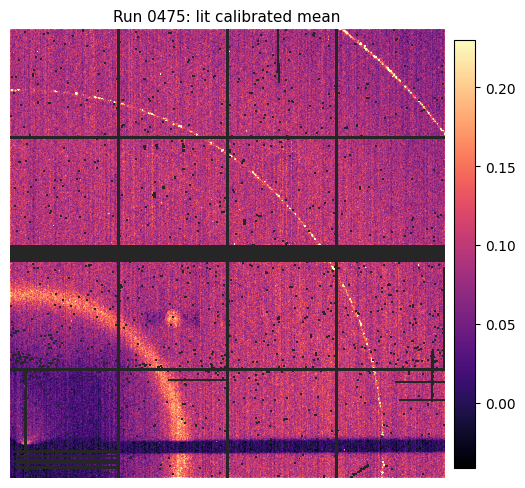

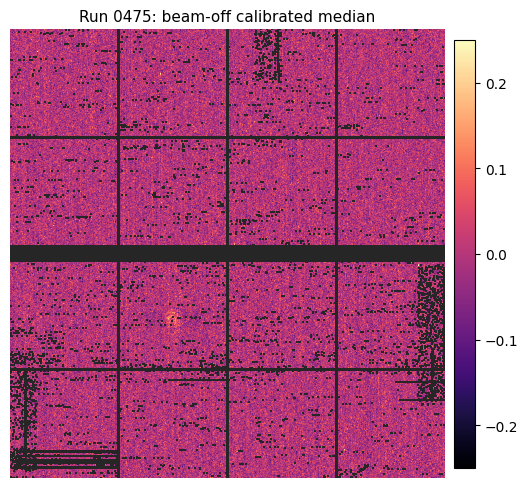

In [7]:
from automask.features import FeatureSpec, FeatureStore
from automask.viz import show

features = {
    'Lit calibrated mean': FeatureSpec('lit_mean', 'mean', LIT_SELECTION),
    'Beam-off calibrated median': FeatureSpec('dark_median', 'median', DARK_SELECTION),
}
store = FeatureStore(shot_meta=ShotMeta.from_profile(run_profile))
selected_images = {name: store.get(RUN, feature) for name, feature in features.items()}

for name, image in selected_images.items():
    show(image, title=f'Run {RUN:04d}: {name.lower()}')

## 3. Masking

### Hardcoded masking techniques and parameters.

<Axes: title={'center': 'Run 0475: 9.99% masked'}>

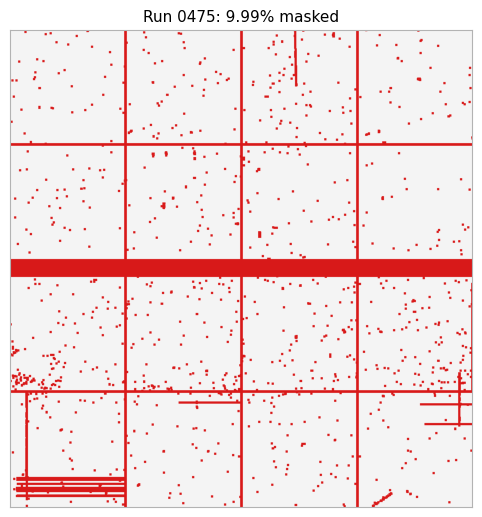

In [8]:
from types import SimpleNamespace
from automask.dataset import load_mask
from automask.masking import Detector, Pipeline
from automask.stats.blackhat import BlackhatParams
from automask.regularization.tv import TVParams
from automask.regularization.pad import PadParams
from automask.viz import show_mask

MASKING_PIPELINE = Pipeline(
    detectors=[Detector(
        stat='blackhat',
        stat_params=BlackhatParams(radius=5, k=6.0, mode='high'),
        field_reg='tv',
        field_reg_params=TVParams(weight=1.0),
        mask_reg='pad',
        mask_reg_params=PadParams(pad=2),
    )],
    floor_stats=["geometry", "calib"],
    combiner='union',
)

image = selected_images['Lit calibrated mean']
calib = load_mask(f'statusMask_run{RUN:04d}')
sample = SimpleNamespace(sumimg=image, umean=image, real=image != 0, calib=calib)
computed_mask = MASKING_PIPELINE.run(sample)
show_mask(computed_mask, title=f'Run {RUN:04d}: {computed_mask.mean():.2%} masked')